(04-21-volatiliteit)=

# ARCH, GARCH, realized volatility en de VIX

```{admonition} Waar we zijn in het verhaal
:class: important

**Jaartal.** 1963–2005, van Mandelbrots katoenprijzen tot de MIDAS-regressie van
Ghysels, Santa-Clara en Valkanov.

**Wat we al weten.** In [](#00-01-rendementen) bewees Merton dat de variantie
met fijnere waarnemingen steeds scherper gemeten wordt en het gemiddelde niet.
[De vorige lecture](#04-20-voorspelbaarheid) liet zien wat dat voor het eerste
moment betekent: rendementen zijn hooguit zwak voorspelbaar, en die zwakke
voorspelbaarheid verdwijnt buiten de steekproef. In [](#02-09-black-scholes) lag de
VIX systematisch boven de daarna gerealiseerde volatiliteit, en in
[](#04-19-momentum) verbeterde schalen met voorspelde volatiliteit de Sharpe-ratio
van momentum sterk. Het tweede moment is dus goed meetbaar en bruikbaar; alleen is
nog nergens gezegd *hoe* het voorspeld wordt.

**Welke vraag staat open.** Hoe voorspel je volatiliteit, en is een goed gemeten
variantie genoeg om de beloofde relatie tussen risico en verwacht rendement in de
data te zien?
```

## Overzicht

Santa-Clara vat een van zijn stellingen over wat het vak geleerd heeft samen als:
volatiliteit is voorspelbaar, rendementen nauwelijks {cite}`SantaClara2026`. Deze
lecture gaat over de eerste helft van die zin en over de poging om de twee helften
aan elkaar te knopen. Robert Engle schreef in 1982 een model op waarin de variantie
van vandaag afhangt van de gekwadrateerde schokken van gisteren, en noemde het
*ARCH* (autoregressive conditional heteroskedasticity: een variantie die
voorwaardelijk op het verleden verandert) {cite}`Engle1982`. Tim Bollerslev maakte er
in 1986 met één extra parameter GARCH van {cite}`Bollerslev1986`, veertig jaar later
nog steeds de maatstaf voor elk volatiliteitsmodel. Engle kreeg in 2003 de Nobelprijs
"for methods of analyzing economic time series with time-varying volatility (ARCH)".
Dit werk definieert het tijdvak omdat het van een stylized fact — volatiliteit
klontert — een schatbaar, voorspellend model maakte.

Daarna kwamen twee verfijningen in dezelfde richting. *Realized volatility*
(gerealiseerde volatiliteit: de som van gekwadrateerde intradagrendementen) maakte
van de latente variantie een bijna waarneembare grootheid
{cite}`AndersenBollerslevDieboldLabys2001,AndersenBollerslevDieboldLabys2003`. En de
VIX werd in 2003 de prijs van een variance swap, afgelezen uit de hele optieketen
{cite}`DemeterfiDermanKamalZou1999`.

De tweede helft van de lecture keert de vraag om. Als de variantie zo goed meetbaar
is, dan zou de meest fundamentele relatie uit de theorie — het verwachte excess
rendement van de markt stijgt met haar voorwaardelijke variantie, zoals het ICAPM uit
[](#03-10-merton-icapm) voorspelt — makkelijk te vinden moeten zijn. Dat was ze niet.
French, Schwert en Stambaugh vonden in 1987 een positief maar zwak verband
{cite}`FrenchSchwertStambaugh1987`, Glosten, Jagannathan en Runkle in 1993 een negatief
{cite}`GlostenJagannathanRunkle1993`. Ghysels, Santa-Clara en Valkanov noemden hun
artikel uit 2005 *There is a risk-return trade-off after all*: met een variantie die
als gewogen som van een jaar dagrendementen wordt geschat — een MIDAS-regressie —
vonden ze een risicoaversie van 2,6 met een zeer hoge $t$-waarde
{cite}`GhyselsSantaClaraValkanov2005`. Epistemisch is dit het scharnier van de lecture:
GARCH is een statistische beschrijving van een feit, het ICAPM een theorie met een
toets, en de toets blijkt het moeilijke deel.

We repliceren GARCH en GJR-GARCH op een eeuw dagrendementen, inclusief de crash van
1987; de voorspelkracht van HAR-RV tegenover GARCH voor de maandvariantie; en de
MIDAS-schatting van de risico-rendementsrelatie op de steekproef van het paper en tot
heden. Die laatste replicatie lukt op onze data niet, en de simulatie die eraan
voorafgaat legt uit waarom dat minder vreemd is dan het lijkt.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from arch import arch_model
from scipy import optimize, stats

import hap
from hap import data as hap_data
hap.plotting.setup()

rng = np.random.default_rng(20240101)

## Intuïtie: waarom zou dit waar zijn?

Benoît Mandelbrot bestudeerde in 1963 katoenprijzen en merkte op dat grote
prijsveranderingen de neiging hebben door grote veranderingen gevolgd te worden, van
welk teken ook, en kleine door kleine {cite}`Mandelbrot1963`. Fama vond hetzelfde in de
dagrendementen van de aandelen van de Dow {cite}`Fama1965`. Die observatie zegt niet
dat te voorspellen is of morgen een goede of een slechte dag wordt, wel of morgen een
*grote* dag wordt. In [](#00-01-rendementen) zagen we het in de French-data: de
autocorrelatie van het dagrendement is nul, die van het absolute dagrendement ongeveer
0,30, bij lag 1 en bij lag 6.

Waarom zou dat zo zijn? Nieuws komt in golven: een recessie of een bankencrisis
produceert weken achter elkaar informatie die prijzen verschuift. Handel komt in
golven, omdat beleggers op elkaar reageren en posities in delen afbouwen. En de schok
verandert het risico zelf: een bedrijf waarvan het aandeel daalt, heeft
verhoudingsgewijs meer schuld en dus riskanter eigen vermogen. Dat laatste is de
*leverage-hypothese* van Fischer Black {cite}`Black1976`, en ze voorspelt een
asymmetrie die in de data zit: volatiliteit stijgt meer na een daling dan na een even
grote stijging.

Dat de variantie wél en het gemiddelde niet voorspelbaar is, is economie en
statistiek tegelijk. Een voorspelbaar rendement is geld op straat, en beleggers ruimen
het op; een voorspelbare variantie zegt niets over de richting en dus niets over winst.
En Mertons argument zegt dat een maand dagdata de variantie al redelijk meet, terwijl
een eeuw het gemiddelde nog niet vastlegt.

Op maandag 19 oktober 1987 daalde de S&P 500 met 20,47% en de Dow Jones Industrial
Average met 22,6%, voor beide de grootste daling op één dag. Een deel van de verkopen
kwam van *portfolio insurance* (portefeuilleverzekering: een putoptie op de
portefeuille die dynamisch wordt nagebootst door bij dalende koersen aandelen te
verkopen), een product dat Hayne Leland en Mark Rubinstein uit de theorie van
[](#02-09-black-scholes) hadden ontwikkeld {cite}`RubinsteinLeland1981`. Een
gerepliceerde put verkoopt precies wanneer iedereen verkoopt. De Brady-commissie zag
portefeuilleverzekering als versterker, niet als oorzaak. Twee gevolgen doen hier
ertoe: sinds 1987 zijn diepe puts duur, de smirk uit [](#fig-black-scholes-smirk); en
een model dat de variantie van gisteren gebruikt om die van vandaag te voorspellen, kan
een crash uit een rustige markt niet zien aankomen, alleen snel reageren zodra hij er
is.

Het laatste stuk intuïtie gaat over risico en rendement. Eisen beleggers compensatie
voor variantie, dan stijgt het verwachte rendement wanneer de voorspelde variantie
stijgt. De toets regresseert het slecht gemeten ding (het rendement van volgende
maand) op het goed gemeten ding (de voorspelde variantie). Het rendement heeft zoveel
ruis dat alleen een grote, precies gemeten spreiding in de variantie een helling
zichtbaar maakt, en elke meetfout in de variantie trekt die helling naar nul. Het
verschil tussen French, Schwert en Stambaugh en Ghysels, Santa-Clara en Valkanov is
grotendeels het verschil in hoe ze die meetfout aanpakten.

## Toy-voorbeeld: vier dagen GARCH met de hand

Neem een GARCH(1,1) voor dagrendementen in procenten met gemiddelde nul,

$$
h_{t+1} = \omega + \alpha\, r_t^2 + \beta\, h_t,
\qquad \omega = 0{,}05,\quad \alpha = 0{,}10,\quad \beta = 0{,}80,
$$

waarbij $h_{t+1}$ de variantie is van $r_{t+1}$, gekend aan het eind van dag $t$. De
onvoorwaardelijke variantie is $\omega/(1-\alpha-\beta) = 0{,}05/0{,}10 = 0{,}5$, een
dagvolatiliteit van 0,71%. We beginnen op dag 1 met $h_1 = 0{,}5$ en nemen vier
rendementen: $+1$, $-2$, $0$ en $-3$ procent.

| dag $t$ | $r_t$ (%) | $h_t$ | berekening van $h_{t+1}$ |
|---|---|---|---|
| 1 | $+1$ | 0,5000 | $0{,}05 + 0{,}10 \cdot 1 + 0{,}80 \cdot 0{,}50 = 0{,}5500$ |
| 2 | $-2$ | 0,5500 | $0{,}05 + 0{,}10 \cdot 4 + 0{,}80 \cdot 0{,}55 = 0{,}8900$ |
| 3 | $0$ | 0,8900 | $0{,}05 + 0{,}10 \cdot 0 + 0{,}80 \cdot 0{,}89 = 0{,}7620$ |
| 4 | $-3$ | 0,7620 | $0{,}05 + 0{,}10 \cdot 9 + 0{,}80 \cdot 0{,}762 = 1{,}5596$ |

De éénstapsvoorspelling aan het eind van dag 4 is $h_5 = 1{,}5596$, een
dagvolatiliteit van 1,25%. Voor dag 6 kennen we $r_5$ nog niet, maar wel
$\E_4[r_5^2] = h_5$, dus

$$
\E_4[h_6] = \omega + \alpha\,\E_4[r_5^2] + \beta\, h_5 = \omega + (\alpha+\beta)\, h_5
          = 0{,}05 + 0{,}90 \cdot 1{,}5596 = 1{,}4536 .
$$

De voorspelling zakt terug naar 0,5 met factor $\alpha + \beta = 0{,}9$ per dag; de
halfwaardetijd van een schok is $\ln 0{,}5/\ln 0{,}9 = 6{,}58$ dagen. De variantie van
het tweedaagse rendement $r_5 + r_6$ is $1{,}5596 + 1{,}4536 = 3{,}0132$. Twee dingen
zijn al zichtbaar: de dag met rendement nul verlaagt de variantie, want de oude schok
sterft uit zonder dat er een nieuwe bijkomt; en één dag van $-3$ verdrievoudigt de
voorspelde variantie ten opzichte van het lange-termijnniveau.

In [2]:
omega, alpha, beta = 0.05, 0.10, 0.80
toy_returns = np.array([1.0, -2.0, 0.0, -3.0])     # percent, days 1-4

h = np.empty(len(toy_returns) + 1)
h[0] = omega / (1 - alpha - beta)                   # h_1 = unconditional variance
for t, r in enumerate(toy_returns):
    h[t + 1] = omega + alpha * r**2 + beta * h[t]

two_step = omega + (alpha + beta) * h[-1]
half_life = np.log(0.5) / np.log(alpha + beta)

assert np.allclose(h, [0.5, 0.55, 0.89, 0.762, 1.5596])
assert np.isclose(two_step, 1.45364)
print("h_1 ... h_5           :", np.round(h, 4))
print(f"E_4[h_6]              : {two_step:.4f}")
print(f"Var_4(r_5 + r_6)      : {h[-1] + two_step:.4f}")
print(f"onvoorwaardelijke var.: {omega / (1 - alpha - beta):.4f}")
print(f"halfwaardetijd (dagen): {half_life:.2f}")

h_1 ... h_5           : [0.5    0.55   0.89   0.762  1.5596]
E_4[h_6]              : 1.4536
Var_4(r_5 + r_6)      : 3.0132
onvoorwaardelijke var.: 0.5000
halfwaardetijd (dagen): 6.58


De code geeft dezelfde vijf varianties, dezelfde tweestapsvoorspelling en dezelfde
halfwaardetijd als de tabel.

## Theorie

### ARCH en GARCH

*Waarom zou dit waar zijn?* Als volatiliteit klontert, is de beste schatting van de
variantie van morgen een gewogen gemiddelde van recente gekwadrateerde schokken, met
meer gewicht voor recente dagen. Een exponentieel gewogen gemiddelde laat zich
recursief schrijven — oude schatting plus een correctie richting de laatste
gekwadrateerde schok — en met een constante die het geheel naar een
lange-termijnniveau trekt, staat GARCH er.

Schrijf $r_{t+1} = \mu + \varepsilon_{t+1}$ met $\varepsilon_{t+1} = \sqrt{h_{t+1}}\, z_{t+1}$,
waarbij $z_{t+1}$ onafhankelijk en gelijk verdeeld is met gemiddelde nul en variantie
één, en $h_{t+1} = \Var_t(r_{t+1})$ op $t$ bekend is. Engles ARCH($q$) laat $h_{t+1}$
lineair afhangen van de laatste $q$ gekwadrateerde schokken; Bollerslevs GARCH voegt
vertraagde varianties toe. Het werkpaard is GARCH(1,1):

```{math}
:label: eq-volatiliteit-garch
h_{t+1} = \omega + \alpha\, \varepsilon_t^2 + \beta\, h_t,
\qquad \omega > 0,\ \alpha \geq 0,\ \beta \geq 0 .
```

Herhaald invullen geeft
$h_{t+1} = \omega/(1-\beta) + \alpha \sum_{j\geq 0} \beta^j \varepsilon_{t-j}^2$: een
ARCH($\infty$) met gewichten die als $\beta^j$ afnemen, en slechts twee parameters.

:::{prf:proposition} GARCH als ARMA-model voor gekwadrateerde schokken
:label: prop-volatiliteit-arma

Definieer $\nu_{t+1} = \varepsilon_{t+1}^2 - h_{t+1}$. Dan is $\E_t[\nu_{t+1}] = 0$, en
onder [](#eq-volatiliteit-garch) volgt $\varepsilon^2$ een ARMA(1,1):

```{math}
:label: eq-volatiliteit-arma
\varepsilon_{t+1}^2 = \omega + (\alpha + \beta)\, \varepsilon_t^2 + \nu_{t+1} - \beta\, \nu_t .
```

Is het vierde moment eindig, dan heeft $\varepsilon_t^2$ een positieve autocorrelatie
die met $(\alpha+\beta)^k$ uitdooft, terwijl $\Corr(\varepsilon_{t+1}, \varepsilon_{t+1-k}) = 0$
voor alle $k \geq 1$.
:::

:::{prf:proof}
$\E_t[\nu_{t+1}] = h_{t+1}\E_t[z_{t+1}^2] - h_{t+1} = 0$. Vervang in
[](#eq-volatiliteit-garch) $h_{t+1}$ door $\varepsilon_{t+1}^2 - \nu_{t+1}$ en $h_t$
door $\varepsilon_t^2 - \nu_t$ en herschik. Een stationaire ARMA(1,1) met
autoregressieve coëfficiënt $\alpha+\beta$ en martingaalverschil-schokken heeft
autocorrelaties die vanaf lag 1 geometrisch dalen met die factor. De schokken zelf zijn
ongecorreleerd: $\E[\varepsilon_{t+1}\varepsilon_{t+1-k}] = \E[\varepsilon_{t+1-k}\sqrt{h_{t+1}}\,\E_t[z_{t+1}]] = 0$,
omdat $z_{t+1}$ onafhankelijk is van alles wat op $t$ bekend is. $\square$
:::

Dat is precies het patroon van Mandelbrot en Fama. Het model levert er een tweede
stylized fact bij: omdat de variantie willekeurig is, is de onvoorwaardelijke verdeling
van $\varepsilon$ een mengsel van normale verdelingen, en zo'n mengsel heeft dikkere
staarten dan zijn componenten ([](#ex-volatiliteit-1) rekent de kurtosis uit).

### Stationariteit, persistentie en de meerstapsvoorspelling

*Waarom zou dit waar zijn?* Een variantie die na elke schok met factor $\alpha+\beta$
terugzakt, heeft een lange-termijnniveau zolang die factor kleiner is dan één; bij één
werkt een schok eeuwig door. De snelheid van terugzakken bepaalt hoe ver vooruit de
voorspelling informatief is.

:::{prf:theorem} Onvoorwaardelijke variantie en meerstapsvoorspelling
:label: thm-volatiliteit-voorspelling

Zij $\phi = \alpha + \beta$. Het proces [](#eq-volatiliteit-garch) is
covariantie-stationair dan en slechts dan als $\phi < 1$, en dan is

```{math}
:label: eq-volatiliteit-onvoorwaardelijk
\bar h \equiv \E[h_t] = \frac{\omega}{1-\alpha-\beta} .
```

De $k$-stapsvoorspelling van de variantie is

```{math}
:label: eq-volatiliteit-kstap
\E_t[h_{t+k}] = \bar h + \phi^{\,k-1}\left(h_{t+1} - \bar h\right), \qquad k \geq 1,
```

de variantie van het cumulatieve rendement over $K$ dagen is
$K\bar h + \frac{1-\phi^K}{1-\phi}(h_{t+1} - \bar h)$, en de halfwaardetijd van een
schok is $\ln(1/2)/\ln\phi$.
:::

:::{prf:proof}
Neem $\E_t$ van [](#eq-volatiliteit-garch) op $t+k$ met $k \geq 2$: omdat
$\E_t[\varepsilon_{t+k-1}^2] = \E_t[h_{t+k-1}]$, is
$\E_t[h_{t+k}] = \omega + \phi\,\E_t[h_{t+k-1}]$, een lineaire differentievergelijking
met vast punt $\bar h$. Dus $\E_t[h_{t+k}] - \bar h = \phi\,(\E_t[h_{t+k-1}] - \bar h)$, en
herhalen tot $k=1$ geeft [](#eq-volatiliteit-kstap). Voor $\phi < 1$ convergeert de
voorspelling naar $\bar h$, en onvoorwaardelijke verwachtingen geven
[](#eq-volatiliteit-onvoorwaardelijk); voor $\phi \geq 1$ is er geen eindige
onvoorwaardelijke variantie. Omdat de schokken ongecorreleerd zijn
([](#prop-volatiliteit-arma)), is de variantie van de som de som van de voorwaardelijke
varianties: tel [](#eq-volatiliteit-kstap) op met de meetkundige reeks. $\square$
:::

Voor dagrendementen op aandelen ligt $\phi$ steevast tussen 0,97 en 0,995: een
halfwaardetijd van weken tot maanden. Op een maandhorizon is de voorspelde variantie
dus informatief, op een jaarhorizon bijna gelijk aan de onvoorwaardelijke. Daarom
heeft de lange-termijnbelegger uit [](#03-10-merton-icapm) weinig aan GARCH en de
risicomanager van [de volgende lecture](#04-22-risk-management) alles.

### Schatten met quasi-maximum likelihood

*Waarom zou dit waar zijn?* Gegeven de parameters is de hele reeks varianties uit te
rekenen, en dan is elk rendement een trekking uit een verdeling met bekende variantie:
de likelihood schrijft zich vanzelf op. Dat $z$ niet normaal is, maakt minder uit dan
het lijkt, want de normale likelihood beloont precies een goed gemiddelde en een goede
variantie.

Met $\theta = (\mu, \omega, \alpha, \beta)$ en $h_{t+1}(\theta)$ recursief uit
[](#eq-volatiliteit-garch) is de Gaussische log-likelihood

```{math}
:label: eq-volatiliteit-qml
\mathcal{L}_T(\theta) = -\frac12 \sum_{t=0}^{T-1}
\left[\ln 2\pi + \ln h_{t+1}(\theta) + \frac{(r_{t+1} - \mu)^2}{h_{t+1}(\theta)}\right] .
```

:::{prf:theorem} Quasi-maximum likelihood (informeel)
:label: thm-volatiliteit-qml

Zijn het voorwaardelijke gemiddelde en de voorwaardelijke variantie correct
gespecificeerd, maar is $z_{t+1}$ niet normaal verdeeld, dan is de maximizer $\hat\theta$
van [](#eq-volatiliteit-qml) onder regulariteitsvoorwaarden consistent en asymptotisch
normaal, met covariantiematrix $A^{-1} B A^{-1}/T$; $A$ is de verwachte Hessiaan van min
de log-likelihood per waarneming en $B$ de verwachte buitenproductmatrix van de scores
{cite}`BollerslevWooldridge1992`.
:::

De kern is één regel. De score naar een parameter die via $h$ binnenkomt, is evenredig
met $(\varepsilon_{t+1}^2/h_{t+1} - 1)\,\partial \ln h_{t+1}/\partial\theta$, en die heeft
verwachting nul zodra $\E_t[\varepsilon_{t+1}^2] = h_{t+1}$, welke verdeling $z$ ook
heeft. Een eerste-ordevoorwaarde met verwachting nul in het ware punt geeft
consistentie. Alleen de informatiematrix-identiteit $A = B$ vervalt; vandaar de sandwich,
die we hieronder voor alle QML-schattingen gebruiken.

### Asymmetrie: leverage, EGARCH en GJR

*Waarom zou dit waar zijn?* Black merkte op dat de volatiliteit van een aandeel stijgt
als de koers daalt, en verklaarde dat met de hefboom van een vaste schuld
{cite}`Black1976`. Een tweede verklaring draait de causaliteit om: stijgt de verwachte
volatiliteit en is volatiliteit beprijsd, dan moet het verwachte rendement stijgen en de
prijs vandaag dalen. Beide voorspellen hetzelfde teken.

GARCH is blind voor het teken van $\varepsilon_t$. Nelson modelleerde daarom de
logaritme van de variantie en liet het teken van de gestandaardiseerde schok apart
meewegen, zonder positiviteitsrestricties, en paste dat EGARCH-model toe op de CRSP
value-weighted index over 1962–1987 {cite}`Nelson1991`:

$$
\ln h_{t+1} = \omega + \beta \ln h_t + \alpha\left(|z_t| - \E|z_t|\right) + \theta_{\mathrm{E}}\, z_t .
$$

Glosten, Jagannathan en Runkle kozen een eenvoudiger route: één term die alleen bij
negatieve schokken aanstaat {cite}`GlostenJagannathanRunkle1993`,

```{math}
:label: eq-volatiliteit-gjr
h_{t+1} = \omega + \left(\alpha + \delta\, \mathbf{1}\{\varepsilon_t < 0\}\right)\varepsilon_t^2 + \beta\, h_t .
```

In het origineel heet $\delta$ de parameter $\gamma$; wij reserveren $\gamma$ voor de
risicoaversie. Bij symmetrische $z$ staat de indicator de helft van de tijd aan, dus de
persistentie is $\alpha + \beta + \delta/2$. Het artikel vond de asymmetrie — "Positive
unanticipated returns appear to result in a downward revision of the conditional
volatility, whereas negative unanticipated returns result in an upward revision of
conditional volatility" — en in dezelfde modellen een *negatief* verband tussen het
voorwaardelijke verwachte rendement en de voorwaardelijke variantie.

### Realized variance en kwadratische variatie

*Waarom zou dit waar zijn?* In [](#thm-rendementen-merton) was de volatiliteit constant
en werd ze scherper gemeten naarmate we vaker keken. Beweegt ze door de tijd, dan is ze
binnen een korte periode bijna constant, en meet de som van gekwadrateerde rendementen
de variantie over die periode. De drift verdwijnt in de limiet, omdat ze in het kwadraat
van orde $\Delta^2$ is.

Laat $d\ell_s = \mu_s\,ds + \sigma_s\,dW_s$ en deel $[t, t+1]$ op in $n$ stukken van
lengte $\Delta = 1/n$, met rendementen $r_{t,i}$. De *realized variance* is
$\mathrm{RV}_{t+1}^{(n)} = \sum_{i=1}^n r_{t,i}^2$, de *integrated variance*
$\mathrm{IV}_{t+1} = \int_t^{t+1} \sigma_s^2\, ds$.

:::{prf:theorem} Realized variance meet integrated variance
:label: thm-volatiliteit-rv

Zijn $\mu$ en $\sigma$ begrensd en onafhankelijk van $W$, dan geldt
$\mathrm{RV}_{t+1}^{(n)} \to \mathrm{IV}_{t+1}$ in kans als $n \to \infty$, met

```{math}
:label: eq-volatiliteit-rv-fout
\sqrt{n}\left(\mathrm{RV}_{t+1}^{(n)} - \mathrm{IV}_{t+1}\right) \;\Rightarrow\;
\mathcal{N}\!\left(0,\ 2\int_t^{t+1}\sigma_s^4\,ds\right) .
```
:::

:::{prf:proof}
We bewijzen de consistentie, voorwaardelijk op het pad van $\mu$ en $\sigma$ (daarvoor is
de onafhankelijkheid van $W$ nodig). Dan is $r_{t,i}$ normaal met gemiddelde $m_i$ en
variantie $v_i = \int \sigma_s^2 ds$ over het $i$-de stuk, met $|m_i| \leq c\Delta$ en
$v_i \leq c\Delta$. Dus $\E[r_{t,i}^2] = v_i + m_i^2$ en
$\Var(r_{t,i}^2) = 2v_i^2 + 4m_i^2 v_i$. Optellen:

$$
\E\big[\mathrm{RV}^{(n)}\big] = \mathrm{IV} + \sum_i m_i^2 = \mathrm{IV} + O(\Delta),
\qquad
\Var\big(\mathrm{RV}^{(n)}\big) = \sum_i \left(2v_i^2 + 4 m_i^2 v_i\right) = O(\Delta),
$$

omdat $\sum_i v_i^2 \leq \max_i v_i \sum_i v_i \leq c\Delta\,\mathrm{IV}$. Chebyshev geeft
convergentie in kans. De variantie $2\sum_i v_i^2 \approx 2\Delta\int\sigma^4$ is de
asymptotische variantie in [](#eq-volatiliteit-rv-fout); de normaliteit volgt uit een
centrale limietstelling voor de onafhankelijke termen $r_{t,i}^2 - v_i$. $\square$
:::

$\mathrm{IV}$ is de *kwadratische variatie* van het proces. Andersen, Bollerslev,
Diebold en Labys maakten er een empirisch programma van: met intradagrendementen
behandelden ze de dagvolatiliteit van wisselkoersen als waargenomen in plaats van
latent {cite}`AndersenBollerslevDieboldLabys2001,AndersenBollerslevDieboldLabys2003`;
Barndorff-Nielsen en Shephard leidden [](#eq-volatiliteit-rv-fout) af
{cite}`BarndorffNielsenShephard2002`. Eerder hadden Andersen en Bollerslev laten zien dat
de lage $R^2$ van GARCH-voorspellingen tegen het gekwadrateerde dagrendement vooral zegt
dat dat kwadraat een slechte meting van de dagvariantie is {cite}`AndersenBollerslev1998`.

```{warning}
Wie elke seconde meet, meet vooral *microstructuurruis*: de waargenomen prijs is de
efficiënte prijs plus een fout $u$ (bid-ask bounce, afronding), zoals in [](#03-14-roll).
Dan is $\E[\mathrm{RV}^{(n)}] = \mathrm{IV} + 2n\,\E[u^2]$ en *divergeert* de schatter
met $n$; de praktijk koos lang voor vijfminutenrendementen. Met de dagdata van French
speelt ruis nauwelijks, maar 21 waarnemingen per maand is weinig.
```

### HAR-RV: een lang geheugen met drie regressoren

*Waarom zou dit waar zijn?* Gerealiseerde volatiliteit dooft veel langzamer uit dan de
geometrische daling van GARCH. Corsi's verklaring: partijen met verschillende
horizonten — dagtraders, wekelijkse herbalanceerders, pensioenfondsen — reageren elk op
de volatiliteit op hun eigen horizon. Drie zulke componenten samen lijken over twee
ordes van grootte op een lang geheugen {cite}`Corsi2009`.

Het *HAR-RV*-model (heterogeneous autoregressive model of realized volatility) is een
OLS-regressie van de gerealiseerde variantie op haar gemiddelden over de laatste dag,
week en maand:

```{math}
:label: eq-volatiliteit-har
\mathrm{RV}_{t+1} = b_0 + b_d\, \mathrm{RV}_t + b_w\, \overline{\mathrm{RV}}_{t-4:t}
                  + b_m\, \overline{\mathrm{RV}}_{t-21:t} + \eta_{t+1} .
```

Zonder intradagdata gebruiken we hieronder de maandversie: maandvariantie uit
dagrendementen, op haar gemiddelden over één, drie en twaalf maanden.

### De VIX als prijs van een variance swap

*Waarom zou dit waar zijn?* Een portefeuille van opties over alle uitoefenprijzen, met
de juiste gewichten, is een weddenschap op de variantie. Het verschil tussen een
continu geherbalanceerde belegging ($dS/S$) en een logcontract ($d\ln S$) is volgens
Itô precies een halve variantie; het logcontract is met opties na te bouwen, en de
herbalancering heeft onder de risiconeutrale maat een bekende verwachting.

De eerste VIX, in 1993 gelanceerd naar een ontwerp van Robert Whaley {cite}`Whaley2000`,
middelde Black-Scholes-implied volatilities van at-the-money-opties op de S&P 100 (die
index heet nu VXO). In 2003 stapte de CBOE over op de S&P 500 en op de modelvrije formule
van Carr en Madan {cite}`CarrMadan2001` en Demeterfi, Derman, Kamal en Zou
{cite}`DemeterfiDermanKamalZou1999`.

:::{prf:theorem} Modelvrije verwachte variantie
:label: thm-volatiliteit-vix

Laat $S$ continu zijn met $dS_t/S_t = r\,dt + \sigma_t\,dW_t^{\mathbb Q}$ en termijnkoers
$F = S_0 e^{rT}$, en zij $Q(K)$ de prijs van de out-of-the-money-optie met
uitoefenprijs $K$ en looptijd $T$ (put voor $K < F$, call voor $K \geq F$). Dan is

```{math}
:label: eq-volatiliteit-vix
\E^{\mathbb Q}\!\left[\frac1T \int_0^T \sigma_t^2\, dt\right]
= \frac{2 e^{rT}}{T} \int_0^\infty \frac{Q(K)}{K^2}\, dK .
```

De CBOE berekent met $T$ gelijk aan dertig dagen de discrete versie
$\mathrm{VIX}^2 = \frac{2e^{rT}}{T}\sum_i \frac{\Delta K_i}{K_i^2} Q(K_i) - \frac1T\left(\frac{F}{K_0}-1\right)^2$.
:::

:::{prf:proof}
Itô geeft $d\ln S_t = dS_t/S_t - \tfrac12\sigma_t^2 dt$, dus
$\int_0^T \sigma_t^2 dt = 2\int_0^T dS_t/S_t - 2\ln(S_T/S_0)$. Onder $\mathbb Q$ is
$\E^{\mathbb Q}[\int_0^T dS_t/S_t] = rT$, en met $\ln(S_T/S_0) = \ln(S_T/F) + rT$ volgt
$\E^{\mathbb Q}[\int_0^T\sigma_t^2 dt] = -2\,\E^{\mathbb Q}[\ln(S_T/F)]$. Voor elke twee
keer differentieerbare $f$ geldt
$f(S_T) = f(F) + f'(F)(S_T - F) + \int_0^F f''(K)(K-S_T)^+ dK + \int_F^\infty f''(K)(S_T-K)^+ dK$.
Met $f = \ln$, $f''(K) = -1/K^2$ en $\E^{\mathbb Q}[S_T - F] = 0$ is
$-\E^{\mathbb Q}[\ln(S_T/F)] = e^{rT}\int_0^\infty Q(K)/K^2\, dK$. Invullen en delen door
$T$. $\square$
:::

De formule gebruikt geen Black-Scholes, alleen dat de koers niet springt. Het gewicht
$1/K^2$ telt diepe puts zwaar mee, zodat de smirk de VIX boven de
at-the-money-volatiliteit tilt; dat de VIX gemiddeld boven de daarna gerealiseerde
volatiliteit ligt, is de variance risk premium uit [](#fig-black-scholes-vrp).
[](#ex-volatiliteit-3) rekent de formule na.

### De risico-rendementsrelatie en het meetfoutprobleem

*Waarom zou dit waar zijn?* In het ICAPM van [](#03-10-merton-icapm) houdt de
representatieve belegger de marktportefeuille. Wil hij meer variantie dragen, dan moet
het verwachte rendement stijgen met zijn relatieve risicoaversie maal de variantie;
zonder hedgingmotieven is dat de hele relatie:

```{math}
:label: eq-volatiliteit-icapm
\E_t\!\left[R^{e}_{t+1}\right] = \mu + \gamma\, \Var_t\!\left(R^{e}_{t+1}\right),
```

met $\mu = 0$ in het zuivere model. French, Schwert en Stambaugh schatten
$\Var_t$ met de gerealiseerde variantie van de vorige maand en met GARCH-in-mean, en
schreven dat "the expected market risk premium ... is positively related to the
predictable volatility of stock returns" en dat "unexpected stock market returns are
negatively related to the unexpected change in the volatility"
{cite}`FrenchSchwertStambaugh1987`. Significant was het eerste verband niet: volgens de
herberekening van Ghysels, Santa-Clara en Valkanov gaf de gerealiseerde variantie over
1928–1984 $\gamma = -0{,}349$ en GARCH-in-mean $7{,}809$, beide insignificant, en kwamen
Glosten, Jagannathan en Runkle met een symmetrische GARCH op $5{,}926$, eveneens
insignificant {cite}`GhyselsSantaClaraValkanov2004`.

:::{prf:proposition} Meetfout in de variantie
:label: prop-volatiliteit-meetfout

Zij $R^{e}_{t+1} = \mu + \gamma V_t + e_{t+1}$ met $\E_t[e_{t+1}] = 0$, en gebruik
$\hat V_t = V_t + u_t$ met $u_t$ ongecorreleerd met $V_t$ en $e_{t+1}$. Dan heeft de
OLS-helling van $R^{e}_{t+1}$ op $\hat V_t$ de kanslimiet

```{math}
:label: eq-volatiliteit-attenuatie
\plim \hat\gamma = \gamma\, \frac{\Var(V_t)}{\Var(V_t) + \Var(u_t)} ,
```

en met de ware variantie is de $t$-waarde na $T$ maanden bij benadering
$\gamma\,\SD(V_t)\sqrt{T}/\SD(R^{e}_{t+1})$.
:::

:::{prf:proof}
$\Cov(R^{e}_{t+1}, \hat V_t) = \gamma\Var(V_t)$ en $\Var(\hat V_t) = \Var(V_t) + \Var(u_t)$;
de OLS-helling convergeert naar de verhouding. Met $u = 0$ is de standaardfout
$\SD(e)/(\SD(V)\sqrt T)$, en omdat $\gamma V$ weinig van het rendement verklaart, is
$\SD(e) \approx \SD(R^{e})$. $\square$
:::

Met een maandrendement van 5% standaarddeviatie, $\gamma = 2{,}5$ en $\SD(V) = 0{,}0015$
vraagt $t = 2$ ongeveer $(2 \cdot 0{,}05/(2{,}5 \cdot 0{,}0015))^2 \approx 700$ maanden,
bijna zestig jaar, *met de ware variantie*. Dat is het 2%-motief in een nieuwe gedaante:
het rendement staat links in de regressie en neemt al zijn ruis mee, en elke meetfout in
$\hat V$ trekt helling en $t$-waarde verder naar nul.

Het antwoord van Ghysels, Santa-Clara en Valkanov is de *MIDAS-regressie* (mixed data
sampling: een laagfrequente variabele op een gewogen som van hoogfrequente
waarnemingen):

```{math}
:label: eq-volatiliteit-midas
V_t^{\mathrm{MIDAS}} = 22 \sum_{d=0}^{D-1} w_d(\theta_1, \theta_2)\, r_{t-d}^2,
\qquad
w_d(\theta_1,\theta_2) = \frac{x_d^{\theta_1-1}(1-x_d)^{\theta_2-1}}{\sum_{j=0}^{D-1} x_j^{\theta_1-1}(1-x_j)^{\theta_2-1}},
\quad x_d = \frac{d+1}{D+1},
```

met $D = 252$ dagen; de factor 22 zet een gemiddeld dagkwadraat om in maandeenheden. Dit
*Beta-lagpolynoom* (de gewichten hebben de vorm van een Beta-dichtheid) kan met twee
parameters dalen, stijgen of een bult hebben. In het risico-rendementsartikel gebruikten
de auteurs als hoofdspecificatie $w_d \propto \exp(\kappa_1 d + \kappa_2 d^2)$ en
meldden ze dat Beta-gewichten dezelfde resultaten geven
{cite}`GhyselsSantaClaraValkanov2004`; in hun artikel over het voorspellen van
volatiliteit staan de Beta-gewichten centraal {cite}`GhyselsSantaClaraValkanov2006`.
Gewichten, $\mu$ en $\gamma$ worden samen geschat met QML onder
$R^e_{t+1} \sim \mathcal N(\mu + \gamma V_t, V_t)$.

Waarom zou dat helpen? Eén maand dagdata is vers maar ruisig, een jaar precies maar oud;
het gewicht laat de likelihood van het *rendement* die afweging maken. De uitkomst in de
werkdocumentversie (NBER 10913, tabel 2), op CRSP-data over 1928–2000: $\gamma = 2{,}606$
met een Bollerslev-Wooldridge-$t$-waarde van $6{,}710$, waarbij 31% van het gewicht op de
eerste 22 dagen valt en pas na meer dan drie maanden 75% is bereikt
{cite}`GhyselsSantaClaraValkanov2004`. De JFE-samenvatting noemt dezelfde 2,6
{cite}`GhyselsSantaClaraValkanov2005`; de tabellen van die versie hebben we niet ingezien.

## Simulatie: clustering, voorspelling en de meetbaarheid van γ

### (a) GARCH-rendementen: kwadraten onthouden, rendementen niet

We simuleren 200 paden van 2520 dagrendementen (tien jaar) uit een GARCH(1,1) met
$\omega = 0{,}02$, $\alpha = 0{,}10$ en $\beta = 0{,}88$ in procenten: onvoorwaardelijke
variantie één, persistentie 0,98. De theoretische autocorrelatie van $r^2$ bij lag 1 is
volgens [](#ex-volatiliteit-1) $\rho_1 = \alpha(1 - \alpha\beta - \beta^2)/(1 - 2\alpha\beta - \beta^2) = 0{,}277$.

In [3]:
N_PATHS, N_DAYS = 200, 2520
OMEGA_S, ALPHA_S, BETA_S = 0.02, 0.10, 0.88
PHI_S = ALPHA_S + BETA_S

h_sim = np.empty((N_DAYS + 1, N_PATHS))
r_sim = np.empty((N_DAYS, N_PATHS))
h_sim[0] = OMEGA_S / (1 - PHI_S)
for t in range(N_DAYS):
    r_sim[t] = np.sqrt(h_sim[t]) * rng.standard_normal(N_PATHS)
    h_sim[t + 1] = OMEGA_S + ALPHA_S * r_sim[t] ** 2 + BETA_S * h_sim[t]


def acf_paths(x, lags):
    """Sample autocorrelations per column, averaged over columns."""
    x = x - x.mean(axis=0)
    denom = (x**2).sum(axis=0)
    return np.array([((x[k:] * x[:-k]).sum(axis=0) / denom).mean() for k in lags])


lags = np.arange(1, 31)
acf_r, acf_r2 = acf_paths(r_sim, lags), acf_paths(r_sim**2, lags)
rho1 = ALPHA_S * (1 - ALPHA_S * BETA_S - BETA_S**2) / (1 - 2 * ALPHA_S * BETA_S - BETA_S**2)
acf_theory = rho1 * PHI_S ** (lags - 1)

pd.DataFrame(
    {"autocorr. r": acf_r, "autocorr. r^2": acf_r2, "theorie r^2": acf_theory},
    index=pd.Index(lags, name="lag"),
).loc[[1, 5, 10, 20, 30]].round(3)

,autocorr. r,autocorr. r^2,theorie r^2
lag,,,
1,-0.002,0.213,0.277
5,0.002,0.195,0.256
10,-0.002,0.168,0.231
20,0.000,0.126,0.189
30,-0.003,0.099,0.154


Nu de voorspelling. Voor 100 paden schatten we GARCH(1,1) met `arch` en vergelijken de
éénstapsvoorspelling met de *ware* $h_{t+1}$, die we in een simulatie kennen. De
concurrenten zijn rollende gemiddelden van gekwadrateerde rendementen over 22, 66 en
252 dagen, de standaard vóór Engle.

In [4]:
N_FIT, BURN = 100, 252
params, mse = [], {"GARCH (geschat)": [], "rollend 22 d": [], "rollend 66 d": [], "rollend 252 d": []}
for i in range(N_FIT):
    fit = arch_model(r_sim[:, i], mean="Zero", vol="GARCH", p=1, q=1).fit(disp="off")
    params.append(fit.params.to_numpy())
    true_h = h_sim[BURN:N_DAYS + 1, i]                       # h_{t+1} for t = BURN-1 .. N_DAYS-1
    garch_h = fit.forecast(horizon=1, start=BURN - 1, reindex=False).variance.to_numpy()[:, 0]
    mse["GARCH (geschat)"].append(np.mean((garch_h - true_h) ** 2))
    sq = pd.Series(r_sim[:, i] ** 2)
    for window in (22, 66, 252):
        rolling = sq.rolling(window).mean().to_numpy()[BURN - 1:N_DAYS]
        mse[f"rollend {window} d"].append(np.mean((rolling - true_h) ** 2))

params = np.array(params)
print("geschat (gem. over paden)  omega, alpha, beta:", params.mean(axis=0).round(3),
      " SD:", params.std(axis=0).round(3))
pd.DataFrame(
    {"MSE t.o.v. ware h": {k: np.mean(v) for k, v in mse.items()},
     "als fractie van Var(h)": {k: np.mean(v) / h_sim[BURN:].var() for k, v in mse.items()}}
).round(4)

geschat (gem. over paden)  omega, alpha, beta: [0.021 0.099 0.879]  SD: [0.006 0.012 0.015]


,MSE t.o.v. ware h,als fractie van Var(h)
GARCH (geschat),0.0051,0.0021
rollend 22 d,0.1124,0.0461
rollend 66 d,0.3802,0.1561
rollend 252 d,0.6820,0.2800


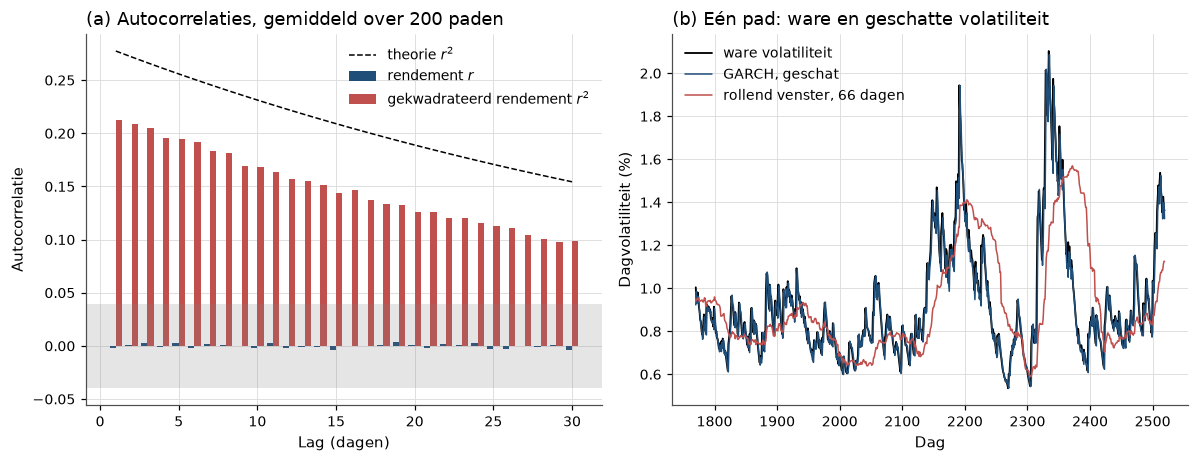

In [5]:
fit0 = arch_model(r_sim[:, 0], mean="Zero", vol="GARCH", p=1, q=1).fit(disp="off")
window = slice(N_DAYS - 750, N_DAYS)
days = np.arange(N_DAYS)[window]

fig, axes = plt.subplots(1, 2, figsize=(11, 4.3))
axes[0].bar(lags - 0.2, acf_r, width=0.4, label="rendement $r$")
axes[0].bar(lags + 0.2, acf_r2, width=0.4, label="gekwadrateerd rendement $r^2$")
axes[0].plot(lags, acf_theory, color="black", ls="--", lw=1, label="theorie $r^2$")
axes[0].axhspan(-2 / np.sqrt(N_DAYS), 2 / np.sqrt(N_DAYS), color="grey", alpha=0.2, lw=0)
axes[0].set_title("(a) Autocorrelaties, gemiddeld over 200 paden")
axes[0].set_xlabel("Lag (dagen)")
axes[0].set_ylabel("Autocorrelatie")
axes[0].legend()
axes[1].plot(days, np.sqrt(h_sim[1:][window, 0]), color="black", lw=1.2, label="ware volatiliteit")
axes[1].plot(days, fit0.conditional_volatility[window], lw=1, label="GARCH, geschat")
axes[1].plot(days, np.sqrt(pd.Series(r_sim[:, 0] ** 2).rolling(66).mean().shift(1))[window],
             lw=1, label="rollend venster, 66 dagen")
axes[1].set_title("(b) Eén pad: ware en geschatte volatiliteit")
axes[1].set_xlabel("Dag")
axes[1].set_ylabel("Dagvolatiliteit (%)")
axes[1].legend()
fig.tight_layout()
plt.show()

:::{figure} #cel-volatiliteit-sim-garch
:label: fig-volatiliteit-sim-garch
:width: 100%

Links: rendementen hebben geen geheugen, hun kwadraten wel. De
steekproefautocorrelaties van $r^2$ liggen onder de theoretische lijn omdat het vierde
moment van deze GARCH net eindig is, en de steekproefautocorrelatie dan langzaam en van
onderen convergeert. Rechts: de geschatte GARCH volgt de ware volatiliteit; het rollende
venster loopt achter en vlakt pieken af.
:::

Tien jaar dagdata leggen $\alpha$ en $\beta$ vast tot op één à twee honderdste, en de
geschatte GARCH voorspelt de ware variantie met een fout van 0,2% van haar spreiding.
Het beste rollende venster, 22 dagen, heeft een ruim twintig keer grotere fout, en
langere vensters zijn slechter omdat ze achterlopen. In [](#04-20-voorspelbaarheid)
waren zestig jaar niet genoeg om te zien of een voorspeller van het *rendement* het
historische gemiddelde verslaat.

### (b) Risico en rendement: hoeveel jaar data vraagt γ?

Nu een wereld waarin [](#eq-volatiliteit-icapm) waar is. De dagvariantie is
$h_d = \bar h\, s_m\, g_d$: een langzame maandcomponent $s_m$ (log-AR(1), persistentie
0,95 per maand, spreiding van $\ln s$ gelijk aan 0,6) maal een snelle GARCH-component
$g_d$ met gemiddelde één, $\alpha = 0{,}04$ en $\beta = 0{,}90$, met Student-$t$-schokken
met vijf vrijheidsgraden. Het dagrendement heeft verwachting $\gamma h_d$ met
$\gamma = 2{,}5$, dus het verwachte maandrendement is exact $\gamma$ maal de
voorwaardelijke maandvariantie; de volatiliteit is 16% per jaar. De wereld bootst twee
eigenschappen van de echte data na: maandvariantie is persistent maar ruisig gemeten, en
dagrendementen hebben dikke staarten.

We simuleren 1000 paden van 150 jaar en schatten $\gamma$ met vier variantieschatters:
de ware (onhaalbaar, als maatstaf), de gerealiseerde variantie van de vorige maand zoals
French, Schwert en Stambaugh, en twee MIDAS-achtige exponentieel gewogen sommen van
dagkwadraten met een halfwaardetijd van 22 en 66 dagen. Die leggen 50% en 21% van het
gewicht op de laatste maand; Ghysels, Santa-Clara en Valkanov schatten 31%, ertussenin.
De gewichten staan vast om de simulatie snel te houden. De helling schatten we met
gewogen kleinste kwadraten met gewichten $1/\hat V_t$, precies de QML-schatter van
$(\mu,\gamma)$ bij gegeven $\hat V_t$.

In [6]:
N_SIM, YEARS_SIM, DAYS_M, GAMMA_TRUE, T_DF = 1000, 150, 22, 2.5, 5
H_BAR = 0.16**2 / 252
PHI_SLOW, SD_LOG_SLOW = 0.95, 0.6
SD_ETA = SD_LOG_SLOW * np.sqrt(1 - PHI_SLOW**2)
MU_LOG_SLOW = -0.5 * SD_LOG_SLOW**2                      # E[s] = 1
A_FAST, B_FAST = 0.04, 0.90
PHI_FAST = A_FAST + B_FAST
T_SCALE = np.sqrt((T_DF - 2) / T_DF)                     # unit-variance Student-t
HALF_LIVES = {"MIDAS-achtig, halfwaarde 22 d": 22, "MIDAS-achtig, halfwaarde 66 d": 66}
lam = {k: 0.5 ** (1 / hl) for k, hl in HALF_LIVES.items()}

n_months = 12 * YEARS_SIM
R_sim = np.zeros((n_months, N_SIM))
V_sim = {k: np.zeros((n_months, N_SIM))
         for k in ["ware variantie", "RV vorige maand (FSS)", *HALF_LIVES]}
log_s = MU_LOG_SLOW + SD_LOG_SLOW * rng.standard_normal(N_SIM)
g = np.ones(N_SIM)
ewma = {k: np.full(N_SIM, H_BAR) for k in lam}
rv_last = np.full(N_SIM, H_BAR * DAYS_M)
geometric = PHI_FAST ** np.arange(DAYS_M)

for month in range(-24, n_months):                        # 24 burn-in months
    if month >= 0:                                        # forecasts at the end of the previous month
        expected_s = np.exp(MU_LOG_SLOW * (1 - PHI_SLOW) + PHI_SLOW * log_s + 0.5 * SD_ETA**2)
        V_sim["ware variantie"][month] = H_BAR * expected_s * (DAYS_M + (g - 1) * geometric.sum())
        V_sim["RV vorige maand (FSS)"][month] = rv_last
        for k in lam:
            V_sim[k][month] = DAYS_M * ewma[k]
    log_s = MU_LOG_SLOW * (1 - PHI_SLOW) + PHI_SLOW * log_s + SD_ETA * rng.standard_normal(N_SIM)
    s = np.exp(log_s)
    month_return, rv_last = np.zeros(N_SIM), np.zeros(N_SIM)
    for _ in range(DAYS_M):
        h_day = H_BAR * s * g
        z = rng.standard_t(T_DF, N_SIM) * T_SCALE
        shock = np.sqrt(h_day) * z
        month_return += GAMMA_TRUE * h_day + shock
        rv_last += shock**2
        for k in lam:
            ewma[k] = lam[k] * ewma[k] + (1 - lam[k]) * shock**2
        g = (1 - PHI_FAST) + A_FAST * g * z**2 + B_FAST * g
    if month >= 0:
        R_sim[month] = month_return

print(f"gemiddelde maandvariantie {V_sim['ware variantie'].mean():.5f}, "
      f"SD {V_sim['ware variantie'].std():.5f}; "
      f"AR(1) van RV: {np.mean([pd.Series(V_sim['RV vorige maand (FSS)'][:, i]).autocorr() for i in range(100)]):.2f}")

gemiddelde maandvariantie 0.00224, SD 0.00148; AR(1) van RV: 0.45


In [7]:
def wls_slope(y, x):
    """Column-wise WLS slope of y on x with weights 1/x and a White standard error."""
    w = (1 / x) / (1 / x).sum(axis=0)
    x_bar, y_bar = (w * x).sum(axis=0), (w * y).sum(axis=0)
    sxx = (w * (x - x_bar) ** 2).sum(axis=0)
    slope = (w * (x - x_bar) * (y - y_bar)).sum(axis=0) / sxx
    resid = (y - y_bar) - slope * (x - x_bar)
    se = np.sqrt((w**2 * (x - x_bar) ** 2 * resid**2).sum(axis=0)) / sxx
    return slope, slope / se


horizons = (25, 50, 73, 100, 150)
gamma_hat, rows = {}, []
for years in horizons:
    for name, V in V_sim.items():
        slope, tval = wls_slope(R_sim[: 12 * years], V[: 12 * years])
        gamma_hat[(years, name)] = slope
        rows.append({"jaren": years, "variantieschatter": name,
                     "gem. gamma": slope.mean(), "SD gamma": slope.std(),
                     "RMSE": np.sqrt(np.mean((slope - GAMMA_TRUE) ** 2)),
                     "fractie t > 1.96": (tval > 1.96).mean()})
sim_table = pd.DataFrame(rows).set_index(["jaren", "variantieschatter"]).round(3)
sim_table.loc[[73, 150]]

gem. gamma  SD gamma   RMSE  \
jaren variantieschatter                                            
73    ware variantie                      2.497     1.332  1.332   
      RV vorige maand (FSS)               1.685     1.044  1.325   
      MIDAS-achtig, halfwaarde 22 d       1.975     1.153  1.266   
      MIDAS-achtig, halfwaarde 66 d       2.152     1.301  1.346   
150   ware variantie                      2.508     0.915  0.915   
      RV vorige maand (FSS)               1.680     0.738  1.103   
      MIDAS-achtig, halfwaarde 22 d       1.977     0.798  0.954   
      MIDAS-achtig, halfwaarde 66 d       2.152     0.893  0.958   

                                     fractie t > 1.96  
jaren variantieschatter                                
73    ware variantie                            0.462  
      RV vorige maand (FSS)                     0.366  
      MIDAS-achtig, halfwaarde 22 d             0.400  
      MIDAS-achtig, halfwaarde 66 d             0.366  
150   ware variantie                            0.773  
      RV vorige maand (FSS)                     0.629  
      MIDAS-achtig, halfwaarde 22 d             0.679  
      MIDAS-achtig, halfwaarde 66 d             0.646

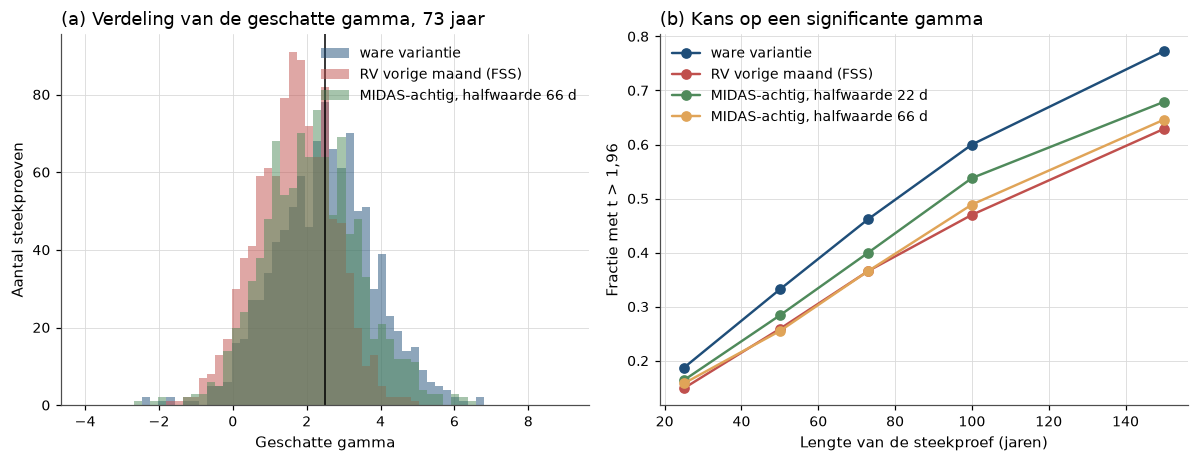

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.3))
bins = np.linspace(-4, 9, 60)
for name in ["ware variantie", "RV vorige maand (FSS)", "MIDAS-achtig, halfwaarde 66 d"]:
    axes[0].hist(gamma_hat[(73, name)], bins=bins, alpha=0.5, label=name)
axes[0].axvline(GAMMA_TRUE, color="black", lw=1)
axes[0].set_title("(a) Verdeling van de geschatte gamma, 73 jaar")
axes[0].set_xlabel("Geschatte gamma")
axes[0].set_ylabel("Aantal steekproeven")
axes[0].legend()
power = sim_table["fractie t > 1.96"].unstack()
for name in V_sim:
    axes[1].plot(horizons, power[name].loc[list(horizons)], marker="o", label=name)
axes[1].set_title("(b) Kans op een significante gamma")
axes[1].set_xlabel("Lengte van de steekproef (jaren)")
axes[1].set_ylabel("Fractie met t > 1,96")
axes[1].legend()
fig.tight_layout()
plt.show()

:::{figure} #cel-volatiliteit-sim-gamma
:label: fig-volatiliteit-sim-gamma
:width: 100%

Links: met de gerealiseerde variantie van één maand ligt de verdeling van $\hat\gamma$
duidelijk links van de ware 2,5; met langere MIDAS-achtige gewichten schuift ze naar de
waarheid. Rechts: ook met de ware variantie is de kans op een significante $\gamma$ na
73 jaar kleiner dan een muntworp.
:::

Drie resultaten. Het eerste is [](#prop-volatiliteit-meetfout) in actie: met de
gerealiseerde variantie van de vorige maand is de gemiddelde $\hat\gamma$ na 73 jaar
1,7 in plaats van 2,5, een derde van de helling verdwijnt in de meetfout van 22
dikstaartige dagrendementen. De MIDAS-achtige schatters komen op 2,0 en 2,2.

Het tweede: zuiverheid is geen onderscheidend vermogen. De langere gewichten hebben een
grotere spreiding, de RMSE is voor alle vier schatters ongeveer 1,3, en de kans op
$t > 1{,}96$ verschilt hooguit enkele procentpunten. De efficiëntiewinst zit hier vooral in
de *grootte* van $\hat\gamma$ — van 1,7 naar 2,2, het verschil dat Ghysels, Santa-Clara en
Valkanov tussen French-Schwert-Stambaugh en henzelf beschreven — niet in de $t$-waarde.

Het derde is motief 1, en het belangrijkste. Zelfs met de ware variantie is $\gamma$ na
73 jaar in 46% van de steekproeven significant, na 150 jaar in 77%. Dat klopt met de
vuistregel: $\SD(V) = 0{,}0015$ vraagt ongeveer zestig jaar voor een verwachte $t$ van
twee. Een $t$ van 6,7 in 73 jaar vraagt een ruim drie keer zo grote spreiding van de
variantie. De echte data hebben die spreiding wel, maar ze komt uit een handvol episodes
— 1929–1933, oktober 1987, najaar 2008, maart 2020 — en dan hangt de schatting aan wat er
in die paar maanden gebeurde.

## Replicatie op echte data

### GARCH en GJR-GARCH op een eeuw dagrendementen

```{admonition} Replicatie
:class: seealso

**Bron.** Tim Bollerslev, *Generalized Autoregressive Conditional Heteroskedasticity*,
Journal of Econometrics 1986 {cite}`Bollerslev1986`; Glosten, Jagannathan en Runkle,
*On the Relation between the Expected Value and the Volatility of the Nominal Excess
Return on Stocks*, Journal of Finance 1993 {cite}`GlostenJagannathanRunkle1993`.

**Wat.** De twee kwalitatieve kernresultaten: een persistentie dicht bij één, en een
asymmetrie $\delta > 0$. Plus de conditionele volatiliteit rond 19 oktober 1987.

**Data hier.** Dagelijkse excess rendementen van de Amerikaanse markt uit de Kenneth
French Data Library (`hap.data.market_daily()`), 1926-07 t/m 2026-07, in procenten.

**Verschil met het origineel.** Glosten, Jagannathan en Runkle schatten op een andere
steekproef en voegden seizoenstermen en de nominale rente aan de variantievergelijking
toe; wij schatten de twee standaardmodellen met normale QML op een eeuw dagdata.

**Verwachte afwijking.** $\alpha + \beta$ tussen 0,97 en 1; $\delta$ positief en vele
standaardfouten van nul, met de symmetrische $\alpha$ in GJR veel kleiner dan in GARCH;
de conditionele volatiliteit op 19 oktober 1987 ver onder die van de dag erna. Wijkt het
teken van $\delta$ af, dan zit er een fout in de code.
```

In [9]:
market = hap_data.market_daily()
excess_pct = 100 * market["Mkt-RF"].dropna()

fits = {
    "GARCH(1,1)": arch_model(excess_pct, mean="Constant", vol="GARCH", p=1, q=1).fit(disp="off"),
    "GJR-GARCH(1,1)": arch_model(excess_pct, mean="Constant", vol="GARCH", p=1, o=1, q=1).fit(disp="off"),
}

rows = {}
for name, res in fits.items():
    p, tv = res.params, res.tvalues
    persistence = p["alpha[1]"] + p["beta[1]"] + 0.5 * p.get("gamma[1]", 0.0)
    rows[name] = {
        "mu": p["mu"], "omega": p["omega"], "alpha": p["alpha[1]"],
        "delta (asymmetrie)": p.get("gamma[1]", np.nan), "t(delta)": tv.get("gamma[1]", np.nan),
        "beta": p["beta[1]"], "persistentie": persistence,
        "halfwaardetijd (dagen)": np.log(0.5) / np.log(persistence),
        "log-likelihood": res.loglikelihood,
    }
pd.DataFrame(rows).T.round(4)

,mu,omega,alpha,delta (asymmetrie),t(delta),beta,persistentie,halfwaardetijd (dagen),log-likelihood
"GARCH(1,1)",0.0561,0.0137,0.1050,NaN,NaN,0.8838,0.9888,61.4385,-32480.5004
"GJR-GARCH(1,1)",0.0379,0.0151,0.0363,0.113,9.8424,0.8903,0.9832,40.8079,-32211.0388


In [10]:
crash = pd.DataFrame({
    "rendement (%)": excess_pct.loc["1987-10-14":"1987-10-23"],
    **{f"vol {name} (%/dag)": res.conditional_volatility.loc["1987-10-14":"1987-10-23"]
       for name, res in fits.items()},
})
crash["z-score GJR"] = fits["GJR-GARCH(1,1)"].std_resid.loc["1987-10-14":"1987-10-23"]
print("hoogste conditionele volatiliteit:",
      {name: f"{res.conditional_volatility.max():.2f}% op {res.conditional_volatility.idxmax().date()}"
       for name, res in fits.items()})
crash.round(2)

hoogste conditionele volatiliteit: {'GARCH(1,1)': '6.49% op 1929-11-07', 'GJR-GARCH(1,1)': '7.14% op 1987-10-20'}


,rendement (%),"vol GARCH(1,1) (%/dag)","vol GJR-GARCH(1,1) (%/dag)",z-score GJR
date,,,,
1987-10-14,-2.44,1.06,1.11,-2.24
1987-10-15,-2.26,1.29,1.42,-1.62
1987-10-16,-4.88,1.43,1.61,-3.05
1987-10-19,-17.44,2.09,2.44,-7.17
1987-10-20,0.75,6.00,7.14,0.10
1987-10-21,8.57,5.65,6.74,1.27
1987-10-22,-3.96,5.99,6.56,-0.61
1987-10-23,-0.60,5.78,6.38,-0.10


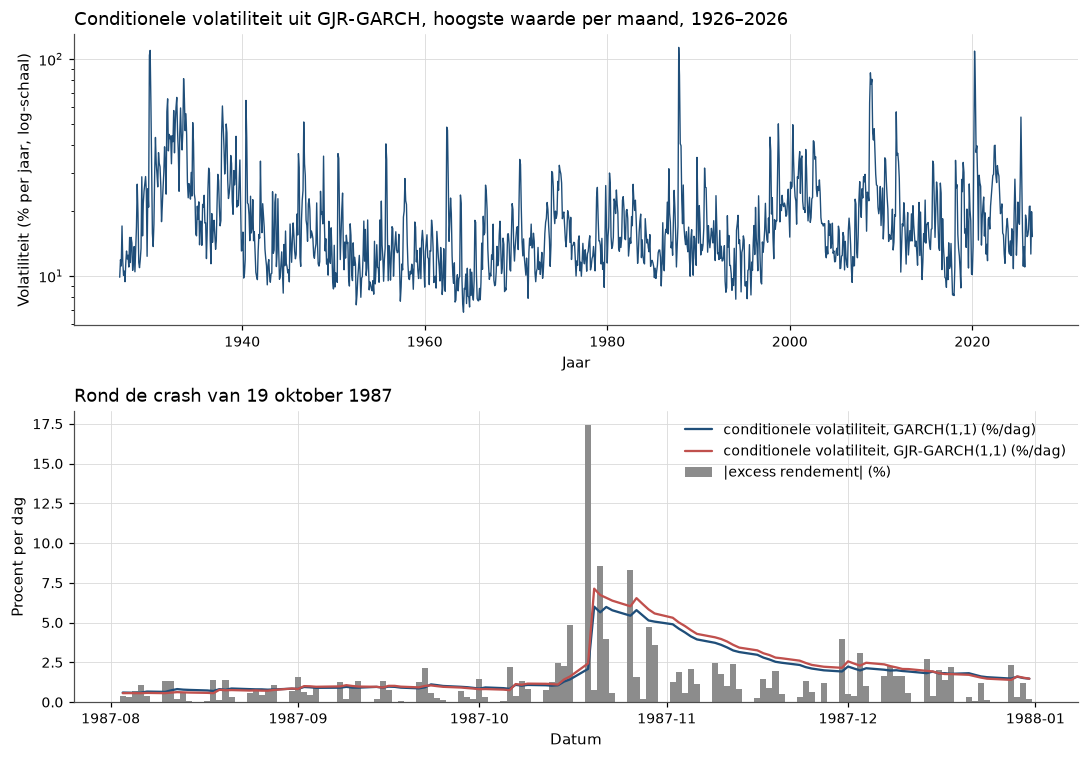

In [11]:
gjr_vol = fits["GJR-GARCH(1,1)"].conditional_volatility * np.sqrt(252)
monthly_max = gjr_vol.resample("ME").max()
zoom = slice("1987-08-01", "1987-12-31")

fig, axes = plt.subplots(2, 1, figsize=(10, 7))
axes[0].plot(monthly_max.index, monthly_max, lw=0.9)
axes[0].set_yscale("log")
axes[0].set_title("Conditionele volatiliteit uit GJR-GARCH, hoogste waarde per maand, 1926–2026")
axes[0].set_xlabel("Jaar")
axes[0].set_ylabel("Volatiliteit (% per jaar, log-schaal)")
axes[1].bar(excess_pct.loc[zoom].index, excess_pct.loc[zoom].abs(), width=1.0,
            color=hap.plotting.COLORS[7], label="|excess rendement| (%)")
for name, res in fits.items():
    axes[1].plot(res.conditional_volatility.loc[zoom].index, res.conditional_volatility.loc[zoom],
                 lw=1.5, label=f"conditionele volatiliteit, {name} (%/dag)")
axes[1].set_title("Rond de crash van 19 oktober 1987")
axes[1].set_xlabel("Datum")
axes[1].set_ylabel("Procent per dag")
axes[1].legend()
fig.tight_layout()
plt.show()

:::{figure} #cel-volatiliteit-garch-markt
:label: fig-volatiliteit-garch-markt
:width: 95%

Boven: volatiliteit klontert in episodes — de jaren dertig, 1987, 2008, 2020 — en zakt
daarna telkens terug. Onder: op 19 oktober 1987 voorspelden beide modellen een licht
verhoogde dagvolatiliteit van ongeveer 2%; na de crash sprong die voorspelling in één
dag naar 6 à 7%. Het model reageert, maar voorziet niet.
:::

De persistentie van GARCH is 0,989 (halfwaardetijd 61 handelsdagen), die van GJR 0,983
(41 dagen). De asymmetrie $\delta = 0{,}11$ ligt bijna tien standaardfouten van nul, en
de symmetrische $\alpha$ zakt van 0,105 naar 0,036: een daling van twee procent verhoogt
de variantie van morgen ruim vier keer zoveel als een even grote stijging. De
log-likelihood stijgt met 269 punten voor één extra parameter.

De crash laat zien wat deze modellen niet kunnen. Op de ochtend van 19 oktober 1987 was
de voorspelde dagvolatiliteit 2,1% (GARCH) of 2,4% (GJR): verhoogd na een slechte week,
niet uitzonderlijk. Het excess rendement die dag was $-17{,}4\%$ in de French-reeks, een
gestandaardiseerde schok van $-7{,}2$ in GJR, onder een normale verdeling eens in
tien miljard jaar. Een dag later voorspelde GJR 7,1% per dag, de hoogste waarde van de
eeuw. GARCH en GJR zijn uitstekende modellen voor de *tweede* dag van een crisis.

### Gerealiseerde variantie: HAR-RV tegen GARCH

```{admonition} Replicatie
:class: seealso

**Bron.** Fulvio Corsi, *A Simple Approximate Long-Memory Model of Realized
Volatility*, Journal of Financial Econometrics 2009 {cite}`Corsi2009`; Andersen,
Bollerslev, Diebold en Labys, *Modeling and Forecasting Realized Volatility*,
Econometrica 2003 {cite}`AndersenBollerslevDieboldLabys2003`.

**Wat.** De voorspelbaarheid van gerealiseerde variantie: de $R^2$ van HAR-RV tegenover
GARCH, buiten de steekproef.

**Data hier.** Maandelijkse gerealiseerde variantie als som van gekwadrateerde dagelijkse
excess rendementen uit `hap.data.market_daily()`. Voorspellingen vanaf januari 1970: HAR
met een uitdijend venster, GARCH en GJR met parameters geschat op data tot en met 1969.

**Verschil met het origineel.** Beide papers gebruiken intradagrendementen en een
dagelijkse horizon; wij hebben alleen dagrendementen en werken een niveau hoger
(maandvariantie, componenten van één, drie en twaalf maanden), met veel meer meetfout.

**Verwachte afwijking.** $R^2$-waarden van tientallen procenten, hoger in logaritmen dan
in niveaus; HAR en GARCH in dezelfde orde van grootte, en "vorige maand" buiten de
steekproef slechter dan beide. Een negatieve $R^2$ voor HAR of GARCH wijst op een fout in
de timing.
```

In [12]:
daily_ex = market["Mkt-RF"].dropna()
rv = (daily_ex**2).groupby(daily_ex.index.to_period("M")).sum()
rv.index = rv.index.to_timestamp(how="end").normalize()

har = pd.DataFrame({"y": rv.shift(-1), "m1": rv, "m3": rv.rolling(3).mean(),
                    "m12": rv.rolling(12).mean()}).dropna()
SPLIT = pd.Timestamp("1969-12-31")
har_design = sm.add_constant(har[["m1", "m3", "m12"]]).to_numpy()
har_forecast = {}
for position in np.flatnonzero(har.index >= SPLIT):
    coef = np.linalg.lstsq(har_design[:position], har["y"].to_numpy()[:position], rcond=None)[0]
    har_forecast[har.index[position]] = har_design[position] @ coef
har_forecast = pd.Series(har_forecast)

full_har = sm.OLS(har["y"], sm.add_constant(har[["m1", "m3", "m12"]])).fit()
print("HAR-coefficienten, volledige steekproef:", full_har.params.round(3).to_dict(),
      f" R2 = {full_har.rsquared:.3f}")

HAR-coefficienten, volledige steekproef: {'const': 0.001, 'm1': 0.404, 'm3': 0.026, 'm12': 0.356}  R2 = 0.337


In [13]:
forecasts = {"HAR-RV": har_forecast, "RV vorige maand": har.loc[SPLIT:, "m1"]}
for name, kw in (("GARCH(1,1)", dict(p=1, q=1)), ("GJR-GARCH(1,1)", dict(p=1, o=1, q=1))):
    model = arch_model(excess_pct, mean="Constant", vol="GARCH", **kw)
    res = model.fit(last_obs=SPLIT, disp="off")                     # parameters from data up to 1969
    path = res.forecast(horizon=22, start=pd.Timestamp("1969-12-01"), reindex=False)
    month_var = path.variance.sum(axis=1) / 1e4                     # next 22 days, back to decimals
    month_var = month_var.groupby(month_var.index.to_period("M")).last()
    month_var.index = month_var.index.to_timestamp(how="end").normalize()
    forecasts[name] = month_var.loc[SPLIT:]

target = har.loc[SPLIT:, "y"]
prevailing = har["y"].expanding().mean().shift(1).loc[SPLIT:]
evaluation = {}
for name, f in forecasts.items():
    f = f.reindex(target.index)
    evaluation[name] = {
        "R2 (niveaus)": sm.OLS(target, sm.add_constant(f)).fit().rsquared,
        "R2 (logs)": sm.OLS(np.log(target), sm.add_constant(np.log(f))).fit().rsquared,
        "OOS R2 t.o.v. hist. gemiddelde": 1 - ((target - f) ** 2).sum() / ((target - prevailing) ** 2).sum(),
    }
print(f"{target.index[0]:%Y-%m} t/m {target.index[-1]:%Y-%m}: {len(target)} maanden")
pd.DataFrame(evaluation).T.round(3)

1969-12 t/m 2026-06: 679 maanden


,R2 (niveaus),R2 (logs),OOS R2 t.o.v. hist. gemiddelde
HAR-RV,0.162,0.414,0.138
RV vorige maand,0.173,0.422,-0.161
"GARCH(1,1)",0.232,0.466,0.123
"GJR-GARCH(1,1)",0.238,0.476,0.174


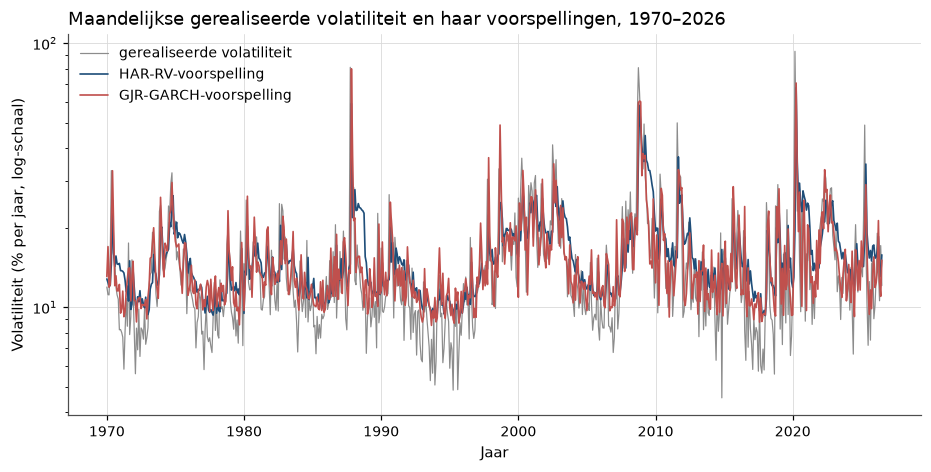

In [14]:
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(target.index, np.sqrt(12 * target) * 100, color=hap.plotting.COLORS[7], lw=0.8,
        label="gerealiseerde volatiliteit")
ax.plot(target.index, np.sqrt(12 * forecasts["HAR-RV"].reindex(target.index)) * 100, lw=1.1,
        label="HAR-RV-voorspelling")
ax.plot(target.index, np.sqrt(12 * forecasts["GJR-GARCH(1,1)"].reindex(target.index)) * 100, lw=1.1,
        label="GJR-GARCH-voorspelling")
ax.set_yscale("log")
ax.set_title("Maandelijkse gerealiseerde volatiliteit en haar voorspellingen, 1970–2026")
ax.set_xlabel("Jaar")
ax.set_ylabel("Volatiliteit (% per jaar, log-schaal)")
ax.legend()
plt.show()

:::{figure} #cel-volatiliteit-har
:label: fig-volatiliteit-har
:width: 95%

Beide voorspellingen volgen het niveau van de volatiliteit over decennia en lopen één
maand achter bij elke piek. Op een lineaire schaal zouden 1987, 2008 en 2020 alles
domineren.
:::

Buiten de steekproef, over 1970–2026, verklaren de modellen 16 tot 24% van de variatie
in het *niveau* van de volgende maandvariantie en 41 tot 48% van haar *logaritme*.
GJR-GARCH is het beste in alle drie de maten; HAR-RV verslaat GARCH(1,1) alleen op de
OOS-$R^2$ tegenover het historische gemiddelde. Dat HAR hier niet wint, weerlegt Corsi
niet: zijn voordeel zit in het combineren van horizonten met intradagdata, en een
maandvariantie uit 21 dagrendementen is te grof. "Vorige maand" heeft in niveaus een
redelijke $R^2$ maar een negatieve OOS-$R^2$: zonder het terugtrekken naar het gemiddelde
uit [](#thm-volatiliteit-voorspelling) overschiet ze na elke piek.

In [](#04-20-voorspelbaarheid) was een OOS-$R^2$ van een paar procent op het maandrendement
al een prestatie. Hier zijn het tientallen procenten, met parameters die in 1969 zijn
vastgezet: Santa-Clara's stelling in één tabel.

### Ghysels, Santa-Clara en Valkanov: is er een risico-rendementsrelatie?

```{admonition} Replicatie
:class: seealso

**Bron.** Eric Ghysels, Pedro Santa-Clara en Rossen Valkanov, *There Is a Risk-Return
Trade-off After All*, Journal of Financial Economics 2005
{cite}`GhyselsSantaClaraValkanov2005`, getallen uit de werkdocumentversie (NBER Working
Paper 10913, 2004) {cite}`GhyselsSantaClaraValkanov2004`.

**Wat.** Tabel 2: $\gamma$ met MIDAS-variantie over 1928–2000 ($2{,}606$, $t = 6{,}710$),
1928–1963 ($1{,}547$, $t = 3{,}382$) en 1964–2000 ($3{,}748$, $t = 8{,}612$). Tabel 4:
$\gamma$ met rollende vensters van één tot zes maanden over 1928–2000.

**Data hier.** Dagelijkse en maandelijkse excess rendementen van de French-markt
(`hap.data.market_daily()`, `hap.data.market_monthly()`), op de steekproef van het paper
en tot heden.

**Verschil met het origineel.** Het paper gebruikt de CRSP value-weighted index, met
dagrendementen van CRSP vanaf juli 1962 en van Schwerts reconstructie daarvoor, en een
risicovrije rente van Ibbotson; wij gebruiken de French-marktfactor, waarvan de dagdata
voor de hele periode uit CRSP komen. Wij schatten Beta-gewichten in plaats van
exponentiële Almon-gewichten, rekenen die laatste als controle met hun gepubliceerde
parameters door, en berekenen de sandwich-standaardfouten numeriek.

**Verwachte afwijking.** Een positieve $\gamma$ over 1928–2000; de grootte kan afwijken,
en de $t$-waarde is volgens de simulatie waarschijnlijk veel kleiner dan 6,7. De
rangorde uit tabel 4 — één maand geeft een kleinere $\gamma$ dan langere vensters — zou
terug moeten komen. Een negatieve MIDAS-$\gamma$ over 1928–2000 betekent dat de replicatie
niet slaagt.
```

In [15]:
LAGS, DAYS_PER_MONTH = 252, 22
monthly_ex = hap_data.market_monthly()["Mkt-RF"].dropna()

position = pd.Series(np.arange(len(daily_ex)), index=daily_ex.index)
month_end = position.groupby(daily_ex.index.to_period("M")).max()
month_end.index = month_end.index.to_timestamp(how="end").normalize()
month_end = month_end[month_end >= LAGS - 1]
squared = daily_ex.to_numpy() ** 2
lagged_sq = pd.DataFrame(np.stack([squared[p - np.arange(LAGS)] for p in month_end.to_numpy()]),
                         index=month_end.index)          # row t: r^2 at lags 0..251 up to month end t
next_return = monthly_ex.shift(-1).reindex(lagged_sq.index)   # R^e_{t+1}


def beta_weights(theta1, theta2, n_lags=LAGS):
    """Normalised Beta lag polynomial w_d for d = 0..n_lags-1."""
    x = np.arange(1, n_lags + 1) / (n_lags + 1)
    log_w = (theta1 - 1) * np.log(x) + (theta2 - 1) * np.log1p(-x)
    w = np.exp(log_w - log_w.max())
    return w / w.sum()


def almon_weights(kappa1, kappa2, n_lags=LAGS):
    """Exponential Almon weights exp(k1 d + k2 d^2), normalised."""
    d = np.arange(n_lags)
    log_w = kappa1 * d + kappa2 * d**2
    w = np.exp(log_w - log_w.max())
    return w / w.sum()


def risk_return_qml(R, variance_of, x0):
    """QML fit of R_{t+1} ~ N(mu + gamma V_t, V_t) with Bollerslev-Wooldridge standard errors.

    theta = (mu, gamma, *extra); variance_of(extra) returns the variance series V_t.
    """  # TODO: naar hap.stats
    def nll_obs(theta):
        V = variance_of(theta[2:])
        return 0.5 * (np.log(2 * np.pi) + np.log(V) + (R - theta[0] - theta[1] * V) ** 2 / V)

    def objective(theta):
        return nll_obs(theta).sum()

    start = optimize.minimize(objective, x0, method="Nelder-Mead",
                              options={"maxiter": 20_000, "xatol": 1e-8, "fatol": 1e-10})
    theta = optimize.minimize(objective, start.x, method="BFGS").x
    k = len(theta)
    step = 1e-5 * np.maximum(np.abs(theta), 1e-2)
    unit = np.eye(k) * step
    scores = np.column_stack([(nll_obs(theta + unit[i]) - nll_obs(theta - unit[i])) / (2 * step[i])
                              for i in range(k)])
    hessian = np.array([[(objective(theta + unit[i] + unit[j]) - objective(theta + unit[i] - unit[j])
                          - objective(theta - unit[i] + unit[j]) + objective(theta - unit[i] - unit[j]))
                         / (4 * step[i] * step[j]) for j in range(k)] for i in range(k)])
    h_inv = np.linalg.inv(hessian)
    se = np.sqrt(np.diag(h_inv @ scores.T @ scores @ h_inv))
    return theta, se, -objective(theta)


def sample(first, last, drop=()):
    """R_{t+1} and lagged squares for return months first..last, minus (start, end) ranges in drop."""
    ret_month = lagged_sq.index + pd.offsets.MonthEnd(1)
    keep = (ret_month >= pd.Timestamp(first)) & (ret_month <= pd.Timestamp(last)) & next_return.notna()
    for a, b in drop:
        keep &= ~((ret_month >= pd.Timestamp(a)) & (ret_month <= pd.Timestamp(b)))
    return next_return[keep].to_numpy(), lagged_sq[keep].to_numpy()

In [16]:
published = {"1928-2000": (2.606, 6.710), "1928-1963": (1.547, 3.382),
             "1964-2000": (3.748, 8.612), "1928-2026": (np.nan, np.nan)}
periods = {"1928-2000": ("1928-01-31", "2000-12-31"), "1928-1963": ("1928-01-31", "1963-12-31"),
           "1964-2000": ("1964-01-31", "2000-12-31"), "1928-2026": ("1928-01-31", "2026-12-31")}

midas_rows, midas_weights = {}, {}
for label, (first, last) in periods.items():
    R, X = sample(first, last)
    theta, se, _ = risk_return_qml(
        R, lambda e: DAYS_PER_MONTH * X @ beta_weights(np.exp(e[0]), np.exp(e[1])),
        np.array([0.005, 2.0, 0.0, np.log(5.0)]))
    midas_weights[label] = beta_weights(np.exp(theta[2]), np.exp(theta[3]))
    midas_rows[label] = {"maanden": len(R), "gamma (Beta)": theta[1], "t": theta[1] / se[1],
                         "gewicht 1e maand": midas_weights[label][:22].sum(),
                         "gamma GSV": published[label][0], "t GSV": published[label][1]}
pd.DataFrame(midas_rows).T.round(3)

,maanden,gamma (Beta),t,gewicht 1e maand,gamma GSV,t GSV
1928-2000,876.0,0.193,0.171,0.233,2.606,6.710
1928-1963,432.0,-0.994,-0.682,0.200,1.547,3.382
1964-2000,444.0,2.853,1.523,0.319,3.748,8.612
1928-2026,1183.0,0.318,0.380,0.309,NaN,NaN


In [17]:
R, X = sample("1928-01-31", "2000-12-31")
gsv_table4 = {1: (0.546, 0.441), 2: (1.494, 1.532), 3: (2.171, 1.945), 4: (2.149, 2.212), 6: (1.483, 1.316)}
rolling_rows = {}
for months, (g_pub, t_pub) in gsv_table4.items():
    V_rw = DAYS_PER_MONTH * X[:, : DAYS_PER_MONTH * months].mean(axis=1)
    theta, se, _ = risk_return_qml(R, lambda e: V_rw, np.array([0.005, 1.0]))
    rolling_rows[f"rollend, {months} maand(en)"] = {"gamma": theta[1], "t": theta[1] / se[1],
                                                    "gamma GSV": g_pub, "t GSV": t_pub}

w_gsv = almon_weights(-5.141e-3, -10.580e-5)
for label, drop in (("MIDAS, gewichten GSV vast", ()),
                    ("idem, zonder 1929-09 t/m 1933-06", (("1929-09-30", "1933-06-30"),))):
    R_d, X_d = sample("1928-01-31", "2000-12-31", drop)
    V_gsv = DAYS_PER_MONTH * X_d @ w_gsv
    theta, se, _ = risk_return_qml(R_d, lambda e: V_gsv, np.array([0.005, 1.0]))
    rolling_rows[label] = {"gamma": theta[1], "t": theta[1] / se[1],
                           "gamma GSV": 2.606 if not drop else np.nan, "t GSV": 6.710 if not drop else np.nan}
print(f"gewicht op de eerste 22 dagen met de GSV-gewichten: {w_gsv[:22].sum():.3f}")
pd.DataFrame(rolling_rows).T.round(3)

gewicht op de eerste 22 dagen met de GSV-gewichten: 0.307


,gamma,t,gamma GSV,t GSV
"rollend, 1 maand(en)",0.449,0.476,0.546,0.441
"rollend, 2 maand(en)",0.808,0.816,1.494,1.532
"rollend, 3 maand(en)",0.989,0.946,2.171,1.945
"rollend, 4 maand(en)",0.750,0.701,2.149,2.212
"rollend, 6 maand(en)",0.790,0.716,1.483,1.316
"MIDAS, gewichten GSV vast",0.828,0.770,2.606,6.710
"idem, zonder 1929-09 t/m 1933-06",1.972,1.607,NaN,NaN


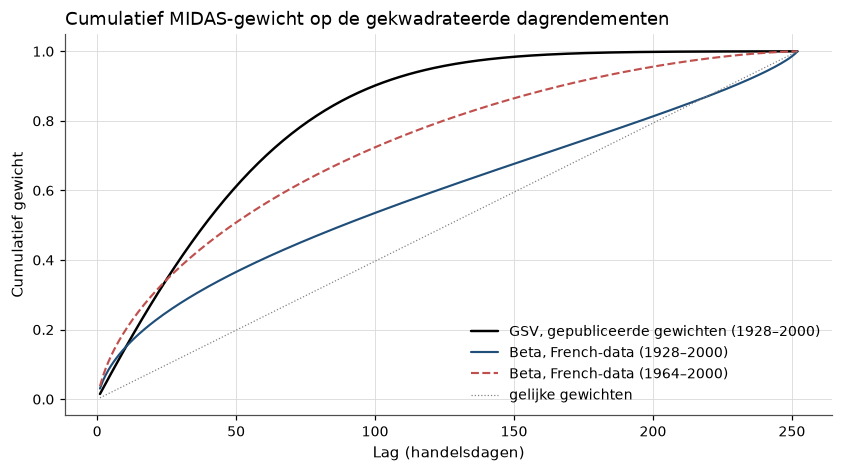

In [18]:
lag_axis = np.arange(1, LAGS + 1)
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(lag_axis, np.cumsum(w_gsv), color="black", lw=1.6, label="GSV, gepubliceerde gewichten (1928–2000)")
ax.plot(lag_axis, np.cumsum(midas_weights["1928-2000"]), lw=1.4, label="Beta, French-data (1928–2000)")
ax.plot(lag_axis, np.cumsum(midas_weights["1964-2000"]), lw=1.4, ls="--", label="Beta, French-data (1964–2000)")
ax.plot(lag_axis, lag_axis / LAGS, color="grey", lw=0.8, ls=":", label="gelijke gewichten")
ax.set_title("Cumulatief MIDAS-gewicht op de gekwadrateerde dagrendementen")
ax.set_xlabel("Lag (handelsdagen)")
ax.set_ylabel("Cumulatief gewicht")
ax.legend()
plt.show()

:::{figure} #cel-volatiliteit-midas
:label: fig-volatiliteit-midas
:width: 90%

De gewichten van Ghysels, Santa-Clara en Valkanov dalen geleidelijk: een derde in de
eerste maand, driekwart na drie à vier maanden. Op de French-data kiest de likelihood
over 1928–2000 een ander profiel, met relatief veel gewicht aan het einde van het jaar;
in 1964–2000 lijkt het meer op het gepubliceerde.
:::

De replicatie slaagt niet, en het loont om precies te zeggen waar. Over 1928–2000 is de
MIDAS-$\gamma$ op de French-data positief maar klein: 0,19 met $t = 0{,}2$. Zelfs met de
gepubliceerde gewichten, zodat alleen $\mu$ en $\gamma$ geschat worden, komt er
$\gamma = 0{,}83$ met $t = 0{,}8$ uit. Het teken klopt; grootte en significantie niet. De
rollende vensters geven hetzelfde beeld: één maand 0,45, twee tot zes maanden 0,75 à 1,0,
alle $t$-waarden onder één; de rangorde uit tabel 4 is er zwak, de piek bij drie à vier
maanden niet. In 1964–2000 komen we dichter bij het paper ($\gamma = 2{,}85$, $t = 1{,}5$,
tegenover $3{,}748$ met $t = 8{,}612$), in 1928–1963 is $\gamma$ negatief, en over de hele
eeuw tot 2026 is ze weer klein en insignificant.

Het verschil zit dus niet in de schatter, want met hun gewichten blijft het bestaan. Het
zit in de data, vooral in de jaren dertig. Zonder september 1929 tot en met juni 1933
stijgt $\gamma$ met dezelfde gewichten naar 1,97 ($t = 1{,}6$). In die jaren draagt een
handvol maanden met extreme variantie de hele schatting, en juist daar verschillen onze
dagdata het meest van de hunne (Schwerts reconstructie uit indexcijfers tegenover
CRSP-dagdata). Ook onze $t$-waarden zijn bij vergelijkbare $\gamma$ veel kleiner, zoals de
simulatie deed verwachten. Ghysels, Plazzi en Valkanov kwamen later tot een verwante
conclusie: de relatie van Merton houdt stand in steekproeven zonder financiële crises, in
het bijzonder zonder de Grote Depressie en de kredietcrisis {cite}`GhyselsPlazziValkanov2016`.

## Wat er brak, en wat daarna kwam

**Wat het model verklaart.** GARCH en zijn opvolgers verklaren met drie parameters drie
stylized facts: rendementen zonder geheugen, kwadraten met een lang geheugen, en dikke
staarten. Op een eeuw French-data zien we een persistentie van 0,98 à 0,99 en een
asymmetrie die bijna de hele reactie op schokken aan dalingen toeschrijft, zoals Black en
Glosten, Jagannathan en Runkle beschreven. Met parameters uit 1969 verklaren
GARCH-voorspellingen tot 2026 bijna een kwart van de variatie in de maandvariantie en
bijna de helft van haar logaritme. Realized variance maakte de variantie meetbaar, de VIX
maakte de verwachte variantie verhandelbaar. Dat volatiliteit voorspelbaar is en
rendementen nauwelijks, is geen theorie maar een feit, en het feit dat Mertons wiskunde
uit [](#00-01-rendementen) voorspelde.

**Waar het breekt.** Op twee plekken, met dezelfde oorzaak. Op 19 oktober 1987 voorspelde
GJR-GARCH een dagvolatiliteit van 2,4% en kwam er $-17{,}4\%$, een schok van $-7{,}2$
standaarddeviaties die onder de normale verdeling van het model niet bestaat:
volatiliteitsmodellen leren van de vorige crisis, niet van de volgende. En de
risico-rendementsrelatie: op de French-data geeft MIDAS over 1928–2000 $\gamma = 0{,}19$ met
$t = 0{,}2$, en de conclusie hangt aan de jaren dertig. De simulatie laat zien dat dit geen
falen van de schatter hoeft te zijn; zelfs met de ware variantie vraagt een risicoaversie
van 2,5 meer dan zeventig jaar om vaker wel dan niet significant te zijn. Het tweede moment
is uitstekend te meten, de *prijs* ervan, die in het eerste moment zit, niet.

**Risico of vergissing?** De Chicago-lezing: volatiliteit is beprijsd risico. Een schok
die de verwachte volatiliteit verhoogt, verhoogt de discontovoet en verlaagt de prijs
vandaag; dat is de negatieve samenhang tussen onverwachte rendementen en onverwachte
volatiliteit die French, Schwert en Stambaugh als indirect bewijs voor een positieve premie
lazen, de asymmetrie in GJR, en de variance risk premium uit [](#02-09-black-scholes). Dat
de relatie buiten crises wel standhoudt, past daarbij als crises toestanden zijn waarin
beleggers naar veiligheid vluchten. De Yale-lezing: in 1987 verkochten
portefeuilleverzekeraars mechanisch in een dalende markt, en in paniek eisen beleggers geen
premie maar vergissen ze zich; wie na een volatiliteitspiek bijkoopt, oogst dan de correctie
van een overreactie, en een VIX boven de latere volatiliteit is een te hoge prijs voor
verzekering. Scheiden vraagt het verwachte rendement in precies de toestanden waarin de
variantie extreem is, en daarvan heeft een eeuw er vier of vijf. Voor Santa-Clara's
praktijkmotief: de strategieën die in deze reeks werken — risico schalen in
[](#04-19-momentum), variantie verkopen in [](#02-09-black-scholes) — leven van het tweede
moment; wie uit volatiliteit het rendement denkt te voorspellen, meent iets te weten wat de
prijs niet weet.

**Wat er daarna kwam.** Een voorspelbare volatiliteit met dikke staarten is precies wat een
risicomanager nodig heeft; ze werd het fundament van Value-at-Risk en RiskMetrics, en van de
rekensommen die LTCM in 1998 niet overleefde: zie [](#04-22-risk-management).

## Oefeningen

:::{exercise}
:label: ex-volatiliteit-1

**Momenten van GARCH(1,1).** Neem [](#eq-volatiliteit-garch) met normale $z$ en
$\phi = \alpha + \beta < 1$.

1. Laat zien dat, als het vierde moment eindig is,
   $\E[h^2] = \dfrac{\omega^2 (1+\phi)}{(1-\phi)(1 - \phi^2 - 2\alpha^2)}$ en de kurtosis
   van $\varepsilon$ gelijk is aan $\kappa = 3(1-\phi^2)/(1-\phi^2-2\alpha^2)$. Wanneer is
   het vierde moment eindig?
2. Leid uit [](#eq-volatiliteit-arma) af dat de autocorrelatie van $\varepsilon^2$ bij lag
   1 gelijk is aan $\rho_1 = \alpha(1-\alpha\beta-\beta^2)/(1-2\alpha\beta-\beta^2)$ en bij
   lag $k$ aan $\rho_1\phi^{k-1}$.
3. Controleer beide met een simulatie voor $\alpha = 0{,}05$, $\beta = 0{,}90$. Waarom is de
   controle voor $\alpha = 0{,}10$, $\beta = 0{,}88$ hierboven minder overtuigend?
:::

:::{solution} ex-volatiliteit-1
:class: dropdown

**(1)** Kwadrateer [](#eq-volatiliteit-garch) en neem verwachtingen, met
$\E[\varepsilon^4] = 3\E[h^2]$ en $\E[\varepsilon^2 h] = \E[h^2]$:
$\E[h^2] = \omega^2 + 2\omega\phi\bar h + (3\alpha^2 + 2\alpha\beta + \beta^2)\E[h^2]$. Omdat
$3\alpha^2 + 2\alpha\beta + \beta^2 = \phi^2 + 2\alpha^2$ en $\bar h = \omega/(1-\phi)$, is
$\E[h^2](1 - \phi^2 - 2\alpha^2) = \omega^2(1+\phi)/(1-\phi)$; dat vraagt
$\phi^2 + 2\alpha^2 < 1$. De kurtosis is $3\E[h^2]/\bar h^2 = 3(1-\phi^2)/(1-\phi^2-2\alpha^2) > 3$.

**(2)** $x_t = \varepsilon_t^2 - \bar h$ volgt $x_{t+1} = \phi x_t + \nu_{t+1} - \beta\nu_t$.
Voor een ARMA(1,1) met AR-coëfficiënt $\phi$ en MA-coëfficiënt $-\beta$ is
$\rho_1 = (1-\phi\beta)(\phi-\beta)/(1 + \beta^2 - 2\phi\beta)$ en $\rho_k = \phi\rho_{k-1}$;
met $\phi - \beta = \alpha$ staat er de formule.

**(3)**

In [19]:
a1, b1, n_paths, n_obs = 0.05, 0.90, 400, 10_000
phi1 = a1 + b1
h1 = np.full(n_paths, 1.0)
eps = np.empty((n_obs, n_paths))
for t in range(n_obs):
    eps[t] = np.sqrt(h1) * rng.standard_normal(n_paths)
    h1 = (1 - phi1) + a1 * eps[t] ** 2 + b1 * h1

pooled = eps.ravel()
kurt_theory = 3 * (1 - phi1**2) / (1 - phi1**2 - 2 * a1**2)
rho1_theory = a1 * (1 - a1 * b1 - b1**2) / (1 - 2 * a1 * b1 - b1**2)
pd.DataFrame(
    {"theorie": [kurt_theory, rho1_theory, rho1_theory * phi1**4],
     "simulatie": [np.mean(pooled**4) / np.mean(pooled**2) ** 2,
                   acf_paths(eps**2, [1])[0], acf_paths(eps**2, [5])[0]]},
    index=["kurtosis", "rho_1 van eps^2", "rho_5 van eps^2"],
).round(3)

,theorie,simulatie
kurtosis,3.162,3.166
rho_1 van eps^2,0.072,0.070
rho_5 van eps^2,0.059,0.058


Met $\phi^2 + 2\alpha^2 = 0{,}91$ liggen simulatie en theorie dicht bij elkaar. Hierboven is
$\phi^2 + 2\alpha^2 = 0{,}98$: het vierde moment bestaat net, het achtste niet, zodat de
steekproefautocorrelatie van $\varepsilon^2$ geen eindige variantie heeft en langzaam en van
onderen convergeert. De oefening leert dat GARCH dikke staarten maakt uit normale schokken,
en dat realistische parameters dicht bij de grens liggen waar klassieke momenten ophouden te
bestaan.
:::

:::{exercise}
:label: ex-volatiliteit-2

**Hoe onmogelijk was 19 oktober 1987?** Schat GJR-GARCH(1,1) op de dagelijkse excess
rendementen van French opnieuw met Student-$t$-schokken (`dist="t"`).

1. Vergelijk log-likelihood en parameters met de normale versie. Hoeveel vrijheidsgraden
   schat het model?
2. Bereken voor beide verdelingen de kans op een gestandaardiseerde schok die minstens zo
   negatief is als die van 19 oktober 1987, en het verwachte aantal jaren tussen zulke dagen.
:::

:::{solution} ex-volatiliteit-2
:class: dropdown

In [20]:
gjr_t = arch_model(excess_pct, mean="Constant", vol="GARCH", p=1, o=1, q=1, dist="t").fit(disp="off")
crash_day = pd.Timestamp("1987-10-19")
comparison = {}
for name, res in (("normaal", fits["GJR-GARCH(1,1)"]), ("Student-t", gjr_t)):
    z_crash = res.std_resid.loc[crash_day]
    if name == "normaal":
        prob = stats.norm.cdf(z_crash)
    else:
        nu = res.params["nu"]
        prob = stats.t.cdf(z_crash * np.sqrt(nu / (nu - 2)), nu)
    comparison[name] = {"log-likelihood": res.loglikelihood, "alpha": res.params["alpha[1]"],
                        "delta": res.params["gamma[1]"], "beta": res.params["beta[1]"],
                        "nu": res.params.get("nu", np.inf), "z op 19-10-1987": z_crash,
                        "kans": prob, "jaren tussen zulke dagen": 1 / (252 * prob)}
pd.DataFrame(comparison).T

,log-likelihood,alpha,delta,beta,nu,z op 19-10-1987,kans,jaren tussen zulke dagen
normaal,-32211.038804,0.036311,0.113017,0.890339,inf,-7.168414,3.793566e-13,1.046048e+10
Student-t,-31352.497578,0.036881,0.117404,0.893494,5.943485,-7.015192,7.096420e-05,5.591910e+01


De Student-$t$-versie wint ruim achthonderd punten log-likelihood en schat ongeveer zes
vrijheidsgraden; de dynamiek ($\alpha$, $\delta$, $\beta$) verandert nauwelijks. De
gestandaardiseerde schok van 19 oktober blijft rond $-7$, maar de kans erop verschuift van
eens in tien miljard jaar naar ruwweg eens in een halve eeuw — een getal waarmee een
risicomanager kan rekenen. De oefening leert dat GARCH de klontering vangt, maar dat de staart
van de voorwaardelijke verdeling een aparte keuze is, en in [](#04-22-risk-management) is dat
de keuze die ertoe doet.
:::

:::{exercise}
:label: ex-volatiliteit-3

**De VIX-formule narekenen.** Neem $S_0 = F = 100$, $r = 0$ en $T = 30/365$.

1. Bereken met Black-Scholes de prijzen van out-of-the-money-puts en -calls bij
   $\sigma = 20\%$ voor uitoefenprijzen van 40 tot 250 in stappen van 1, en pas de
   CBOE-formule uit [](#thm-volatiliteit-vix) toe. Wat gebeurt er als de uitoefenprijzen
   alleen van 95 tot 105 lopen?
2. Geef de keten een smirk, $\sigma(K) = \max\{0{,}20 - 0{,}35 \ln(K/F),\ 0{,}10\}$, en
   vergelijk de modelvrije volatiliteit met de at-the-money implied volatility van 20%.
:::

:::{solution} ex-volatiliteit-3
:class: dropdown

In [21]:
def bs_otm_price(K, F, T, sigma):
    """Undiscounted Black price of the out-of-the-money option (put below F, call above)."""
    d1 = (np.log(F / K) + 0.5 * sigma**2 * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    call = F * stats.norm.cdf(d1) - K * stats.norm.cdf(d2)
    put = K * stats.norm.cdf(-d2) - F * stats.norm.cdf(-d1)
    return np.where(K < F, put, call)


def vix_formula(K, prices, F, T):
    """CBOE discrete model-free volatility (r = 0)."""
    dK = np.gradient(K)
    K0 = K[K <= F].max()
    variance = 2 / T * np.sum(dK / K**2 * prices) - (F / K0 - 1) ** 2 / T
    return np.sqrt(variance)


F0, T0 = 100.0, 30 / 365
vix_rows = {}
for label, (lo, hi) in {"K van 40 tot 250": (40, 250), "K van 95 tot 105": (95, 105)}.items():
    K = np.arange(lo, hi + 1, 1.0)
    vix_rows[f"vlak 20%, {label}"] = vix_formula(K, bs_otm_price(K, F0, T0, 0.20), F0, T0)
K = np.arange(40, 251, 1.0)
smirk_vol = np.maximum(0.20 - 0.35 * np.log(K / F0), 0.10)
vix_rows["smirk, K van 40 tot 250"] = vix_formula(K, bs_otm_price(K, F0, T0, smirk_vol), F0, T0)
pd.Series(vix_rows, name="modelvrije volatiliteit").round(4)

vlak 20%, K van 40 tot 250    0.2005
vlak 20%, K van 95 tot 105    0.1835
smirk, K van 40 tot 250       0.2043
Name: modelvrije volatiliteit, dtype: float64

Met een vlakke implied volatility en een brede keten geeft de formule 20,05%: de modelvrije
variantie is de Black-Scholes-variantie op een discretisatiefout van de gehele
uitoefenprijzen na. Een keten van 95 tot 105 mist de staarten en onderschat de variantie
fors. Met een smirk ligt de modelvrije volatiliteit boven de at-the-money 20%, omdat het
gewicht $1/K^2$ de dure puts zwaarder laat meetellen dan de goedkope calls. De oefening leert
dat de VIX de risiconeutrale verwachte variantie over de hele verdeling meet, inclusief de
crashstaart, en dat een keten met te weinig uitoefenprijzen haar systematisch te laag
schat.
:::

:::{exercise}
:label: ex-volatiliteit-4

**French, Schwert en Stambaugh terug, en zonder crises.** Ghysels, Santa-Clara en Valkanov
schrijven dat ze met de gerealiseerde variantie van één maand over 1928–1984 de
resultaten van French, Schwert en Stambaugh terugkrijgen ($\gamma = -0{,}349$).

1. Schat met `risk_return_qml` de rollende vensters van één en vier maanden over 1928–1984
   met de French-data. Komt het teken terug?
2. Schat de MIDAS-versie met Beta-gewichten over 1952–2026, en over dezelfde periode zonder
   september 2008 tot en met juni 2009 en maart 2020. Wat doet het weglaten van elf maanden
   met $\gamma$?
:::

:::{solution} ex-volatiliteit-4
:class: dropdown

In [22]:
results = {}
R, X = sample("1928-01-31", "1984-12-31")
for months in (1, 4):
    V_rw = DAYS_PER_MONTH * X[:, : DAYS_PER_MONTH * months].mean(axis=1)
    theta, se, _ = risk_return_qml(R, lambda e: V_rw, np.array([0.005, 1.0]))
    results[f"1928-1984, rollend {months} maand(en)"] = {"gamma": theta[1], "t": theta[1] / se[1], "maanden": len(R)}

crises = (("2008-09-30", "2009-06-30"), ("2020-03-31", "2020-03-31"))
for label, drop in (("1952-2026, MIDAS", ()), ("1952-2026, MIDAS zonder 2008-09 en 2020-03", crises)):
    R, X = sample("1952-01-31", "2026-12-31", drop)
    theta, se, _ = risk_return_qml(
        R, lambda e: DAYS_PER_MONTH * X @ beta_weights(np.exp(e[0]), np.exp(e[1])),
        np.array([0.005, 2.0, 0.0, np.log(5.0)]))
    results[label] = {"gamma": theta[1], "t": theta[1] / se[1], "maanden": len(R)}
pd.DataFrame(results).T.round(3)

,gamma,t,maanden
"1928-1984, rollend 1 maand(en)",0.512,0.481,684.0
"1928-1984, rollend 4 maand(en)",0.637,0.522,684.0
"1952-2026, MIDAS",1.284,1.391,895.0
"1952-2026, MIDAS zonder 2008-09 en 2020-03",2.062,2.010,884.0


Over 1928–1984 geeft het venster van één maand op de French-data een kleine positieve
$\gamma$ van ongeveer 0,5 ($t \approx 0{,}5$): het teken van $-0{,}349$ komt niet terug, de
insignificantie wel, en vier maanden verandert daar weinig aan. Over 1952–2026 is de
MIDAS-$\gamma$ ongeveer 1,3 ($t \approx 1{,}4$); zonder elf crisismaanden van de
eenentwintigste eeuw stijgt ze naar ongeveer 2,1 met $t \approx 2{,}0$. De oefening leert dat
de geschatte prijs van variantierisico geen vast getal is maar afhangt van welke extreme
maanden in de steekproef zitten: niet de variantie is slecht gemeten, maar haar beloning.
:::